## 1. Main regression
Men & women & household full sample---regress education and wealth index --- 2014 & 2022 & 2007

In [84]:
print(1)

1


## 1.2022

Total clusters in the 20 km buffer: 721
    ├─ Clusters inside settlement polygons (in 20 km): 61
    └─ Clusters outside settlement polygons (in 20 km): 660


/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_4475/2686245661.py:141: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


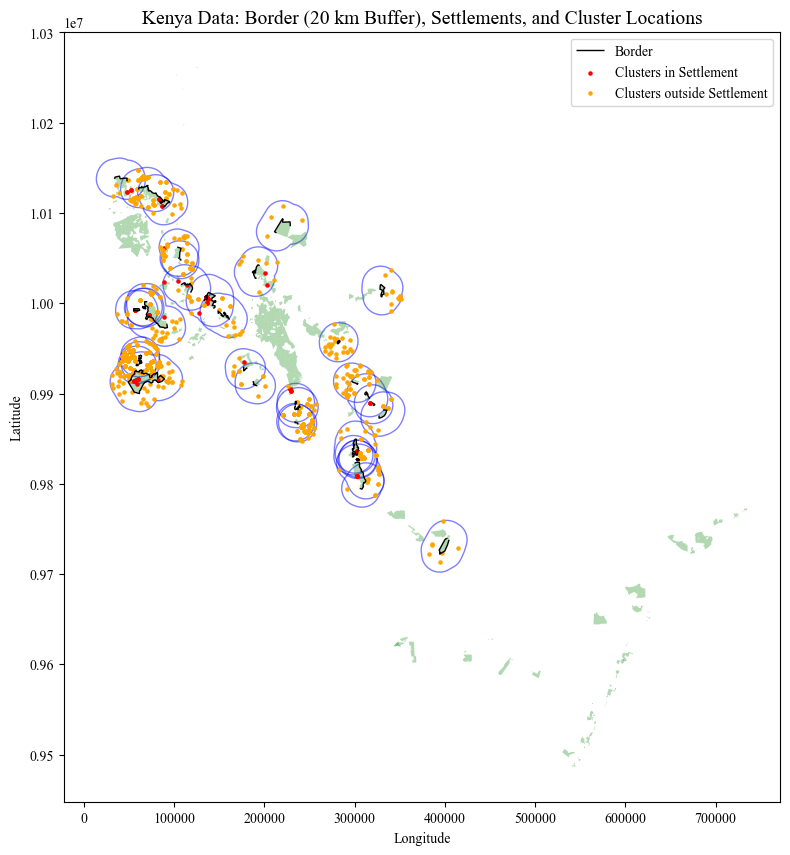

In [23]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. LOAD THE DATA
# ---------------------------------------------------------------------

# 1.1 Load the border shapefile
border_shapefile = gpd.read_file(
    "/Users/huiyu/Downloads/full_border_draft_manual/full_border_test1.shp"
)

# 1.2 Load the settlement (polygon) shapefile
settlement_shapefile_path = "/Users/huiyu/Downloads/2222/MergedFeatures.shp"
settlement_data = gpd.read_file(settlement_shapefile_path)

# 1.3 Load the household cluster shapefile
cluster_shapefile_path = "/Users/huiyu/Documents/uchicago/kenya project/data/KE_2022_DHS_09262024_2355_218744/KEGE8AFL/KEGE8AFL.shp"
data_cluster = gpd.read_file(cluster_shapefile_path)

# ---------------------------------------------------------------------
# 2. PROJECT DATA INTO A SUITABLE METER-BASED CRS FOR KENYA
#    We'll use EPSG:32737 (WGS 84 / UTM zone 37S).
# ---------------------------------------------------------------------

desired_crs = "EPSG:32737"

border_projected = border_shapefile.to_crs(desired_crs)
settlement_projected = settlement_data.to_crs(desired_crs)
cluster_projected = data_cluster.to_crs(desired_crs)


# ---------------------------------------------------------------------
# 2.1 LOAD MARKET DATA AND COMPUTE DISTANCE TO NEAREST MARKET
# ---------------------------------------------------------------------

# Load the market data
market_data = pd.read_excel("/Users/huiyu/Downloads/Markets.xlsx")  # Adjust path if needed

# Create GeoDataFrame for markets
market_gdf = gpd.GeoDataFrame(
    market_data,
    geometry=gpd.points_from_xy(market_data['GPS Longitude'], market_data['GPS Latitude']),
    crs="EPSG:4326"  # Original CRS (longitude/latitude)
)

# Project markets to the same CRS as the cluster data
market_projected = market_gdf.to_crs(desired_crs)

# Project cluster data (if not already projected)
cluster_projected = data_cluster.to_crs(desired_crs)

# Import nearest points function
from shapely.ops import nearest_points

# Define a function to calculate distance from a point to the nearest market
def nearest_market_distance(point, markets):
    nearest_geom = nearest_points(point, markets.unary_union)[1]
    return point.distance(nearest_geom)

# Apply the function: for each cluster point, find its nearest market
cluster_projected["distance_to_nearest_market"] = cluster_projected.geometry.apply(
    lambda pt: nearest_market_distance(pt, market_projected)
)

# ---------------------------------------------------------------------
# 3. CREATE 20 KM BUFFER AROUND THE BORDER
# ---------------------------------------------------------------------

# 3.1 Buffer in meters: 20 km = 20,000 m
border_buffer = border_projected.buffer(20000)

# 3.2 Convert the Series to a GeoDataFrame for spatial operations
border_buffer_gdf = gpd.GeoDataFrame(geometry=border_buffer, crs=desired_crs)

# ---------------------------------------------------------------------
# 4. FIND ALL CLUSTERS WITHIN THE 20 KM BUFFER
# ---------------------------------------------------------------------

clusters_in_20km = gpd.sjoin(
    cluster_projected, border_buffer_gdf, how="inner", predicate="intersects"
)

# ---------------------------------------------------------------------
# 5. WITHIN THOSE CLUSTERS, FIND WHICH ARE INSIDE/OUTSIDE THE SETTLEMENT POLYGONS
# ---------------------------------------------------------------------

# ----- Fix: drop the join-index columns -----
clusters_in_20km = clusters_in_20km.drop(columns=["index_left", "index_right"], errors="ignore")

# 5.1 Clusters within the polygons
clusters_in_20km_in_settlement = gpd.sjoin(
    clusters_in_20km, settlement_projected, how="inner", predicate="within"
)

# 5.2 Clusters outside the polygons (but still within the 20 km buffer)
clusters_in_20km_out_settlement = clusters_in_20km[
    ~clusters_in_20km.index.isin(clusters_in_20km_in_settlement.index)
]

# ---------------------------------------------------------------------
# 6. PRINT SIMPLE COUNTS
# ---------------------------------------------------------------------
print("Total clusters in the 20 km buffer:", len(clusters_in_20km))
print("    ├─ Clusters inside settlement polygons (in 20 km):", len(clusters_in_20km_in_settlement))
print("    └─ Clusters outside settlement polygons (in 20 km):", len(clusters_in_20km_out_settlement))

# ---------------------------------------------------------------------
# 7. PLOT ALL LAYERS ON A SINGLE FIGURE
# ---------------------------------------------------------------------
import matplotlib as mpl

# 2. Set font globally to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(10, 10))

# 7.1 Plot the original border
border_projected.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, label='Border')

# 7.2 Plot the 20 km buffer
border_buffer_gdf.plot(ax=ax, edgecolor='blue', facecolor='none', alpha=0.5, label='20 km Buffer')

# 7.3 Plot the settlement polygons
settlement_projected.plot(ax=ax, color='green', alpha=0.3, label='Settlement Polygons')

# 7.4 Plot the clusters within 20 km & in settlement polygons
clusters_in_20km_in_settlement.plot(ax=ax, color='red', markersize=5, label='Clusters in Settlement')

# 7.5 Plot the clusters within 20 km & outside settlement polygons
clusters_in_20km_out_settlement.plot(ax=ax, color='orange', markersize=5, label='Clusters outside Settlement')

# # 7.6 Customize and show the plot
# ax.set_title("Kenya Data: Border (20 km Buffer), Settlements, and Cluster Locations (UTM 37S)")


ax.set_title("Kenya Data: Border (20 km Buffer), Settlements, and Cluster Locations", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.legend()
plt.show()



In [ ]:
# change style of visualzation


In [198]:

# 1. Compute the unified border geometry (single shape)
# ---------------------------------------------------------------------
border_union = border_projected.unary_union

# ---------------------------------------------------------------------
# 2. Add distance-to-border (in meters) for "in settlement" clusters
# ---------------------------------------------------------------------
clusters_in_20km_in_settlement["dist_to_border_m"] = (
    clusters_in_20km_in_settlement.geometry.distance(border_union)
)

# ---------------------------------------------------------------------
# 3. Add distance-to-border (in meters) for "out settlement" clusters
# ---------------------------------------------------------------------
clusters_in_20km_out_settlement["dist_to_border_m"] = (
    clusters_in_20km_out_settlement.geometry.distance(border_union)
)

# ---------------------------------------------------------------------
# 4. Preview the results
# ---------------------------------------------------------------------
print("\nClusters in settlement (distance to border, first 5 rows):")
print(clusters_in_20km_in_settlement[["geometry", "dist_to_border_m"]].head())

print("\nClusters out settlement (distance to border, first 5 rows):")
print(clusters_in_20km_out_settlement[["geometry", "dist_to_border_m"]].head())


Clusters in settlement (distance to border, first 5 rows):
                           geometry  dist_to_border_m
720  POINT (317572.304 9889775.360)       2213.845117
720  POINT (317572.304 9889775.360)       2213.845117
720  POINT (317572.304 9889775.360)       2213.845117
540  POINT (302237.576 9835828.001)        960.265987
540  POINT (302237.576 9835828.001)        960.265987

Clusters out settlement (distance to border, first 5 rows):
                            geometry  dist_to_border_m
352  POINT (333856.088 10031815.343)      11848.524804
360  POINT (340420.923 10036653.154)      19391.407644
375  POINT (341314.234 10013658.919)       8498.157217
376  POINT (334680.270 10010172.427)       2108.029460
377  POINT (341174.583 10012297.103)       8746.883298


/Users/huiyu/opt/anaconda3/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [199]:
clusters_in_20km_in_settlement=clusters_in_20km_in_settlement.drop_duplicates()
clusters_in_20km_out_settlement=clusters_in_20km_out_settlement.drop_duplicates()
clusters_in_20km_in_settlement["within_settlement"] =1
clusters_in_20km_out_settlement["within_settlement"] = 0

cluster_points = gpd.pd.concat(
    [clusters_in_20km_in_settlement, clusters_in_20km_out_settlement],
    ignore_index=True
)
median_distance = cluster_points["distance_to_nearest_market"].median()
print(f"The median distance to nearest market is {median_distance:.2f} meters.")
# Step 2: Create the new column based on the median
cluster_points["market_distance_above_median"] = cluster_points["distance_to_nearest_market"].apply(
    lambda x: 0 if x > median_distance else 1
)
# match geo cov : test weather and sol
import pandas as pd
### geo cov data: 
# Assuming `geo_cov` and `cluster_data_combined` DataFrames are loaded
geo_cov=pd.read_csv("/Users/huiyu/Documents/uchicago/kenya project/data/KE_2022_DHS_09262024_2355_218744/KEGC8AFL/KEGC8AFL.csv")
# Merge the two DataFrames based on the 'DHSCLUST' column
cluster_points_withgeo = pd.merge(cluster_points, geo_cov, on='DHSCLUST', how='left')

The median distance to nearest market is 3873.21 meters.


/Users/huiyu/opt/anaconda3/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/huiyu/opt/anaconda3/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [203]:
cluster_points_withgeo[cluster_points_withgeo["Year_Regis"] <1990]

,DHSID_x,DHSCC_x,DHSYEAR_x,DHSCLUST,CCFIPS,ADM1FIPS,ADM1FIPSNA,ADM1SALBNA,ADM1SALBCO,ADM1DHS,...,UN_Population_Density_2000,UN_Population_Density_2005,UN_Population_Density_2010,UN_Population_Density_2015,UN_Population_Density_2020,Wet_Days_2000,Wet_Days_2005,Wet_Days_2010,Wet_Days_2015,Wet_Days_2020
9,KE202200000916,KE,2022.0,916.0,KE,NULL,NULL,NULL,NULL,27.0,...,84.672966,99.555359,116.707420,136.009552,156.008118,14.118341,11.949136,16.733082,15.600651,19.659687
11,KE202200001006,KE,2022.0,1006.0,KE,NULL,NULL,NULL,NULL,29.0,...,179.562210,211.122665,247.496277,288.429443,330.839508,14.746084,11.994083,17.482422,14.843463,19.969410
12,KE202200001038,KE,2022.0,1038.0,KE,NULL,NULL,NULL,NULL,30.0,...,463.518097,544.987549,638.881653,744.545654,854.022156,13.611675,12.007782,16.055025,16.541485,19.498575
13,KE202200001039,KE,2022.0,1039.0,KE,NULL,NULL,NULL,NULL,30.0,...,463.518097,544.987549,638.881653,744.545654,854.022156,13.611675,12.007782,16.055025,16.541485,19.498575
14,KE202200001040,KE,2022.0,1040.0,KE,NULL,NULL,NULL,NULL,30.0,...,463.518097,544.987549,638.881653,744.545654,854.022156,13.611675,12.007782,16.055025,16.541485,19.498575
18,KE202200001482,KE,2022.0,1482.0,KE,NULL,NULL,NULL,NULL,42.0,...,257.035065,281.110992,306.532989,332.287292,354.533325,15.757498,13.099816,18.971386,16.211466,21.209799
19,KE202200001035,KE,2022.0,1035.0,KE,NULL,NULL,NULL,NULL,30.0,...,204.295456,240.203125,281.586883,328.158295,376.410004,13.693452,12.097397,16.136791,16.667856,19.610149
21,KE202200001079,KE,2022.0,1079.0,KE,NULL,NULL,NULL,NULL,31.0,...,96.132011,113.028496,132.501785,154.416138,177.121170,10.726809,10.211901,12.692669,15.820025,16.124426
22,KE202200001080,KE,2022.0,1080.0,KE,NULL,NULL,NULL,NULL,31.0,...,92.232292,108.443337,127.126671,148.152054,169.936005,11.110377,10.379830,12.974856,16.184231,16.616484
24,KE202200001259,KE,2022.0,1259.0,KE,NULL,NULL,NULL,NULL,36.0,...,223.647766,262.956818,308.260773,359.243744,412.066162,15.731986,13.706233,19.302862,17.170637,21.894667


In [204]:
cluster_points_withgeo["Year_Regis"]

0      99999.0
1      99999.0
2       2006.0
3       1990.0
4       1990.0
        ...   
412        NaN
413        NaN
414        NaN
415        NaN
416        NaN
Name: Year_Regis, Length: 417, dtype: float64

In [206]:
settlement_data.to_csv("/Users/huiyu/Downloads/test2.csv")

### 1.1.1 women 2022 -edu

In [111]:
#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2022_DHS_09262024_2340_218744/KEIR8CDT/KEIR8CFL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'v001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')

In [114]:
data_test= household_geo[["within_settlement","dist_to_border_m","market_distance_above_median", "distance_to_nearest_market"]]

In [115]:
data_test.to_csv("/Users/huiyu/Downloads/test.csv")

In [89]:
# if is within the settlement area, the distance is positive, otherwise negative
household_geo.loc[
    household_geo["within_settlement"] == 1, 
    "dist_to_border_m"
] *= -1

In [90]:
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["v106", "dist_to_border_m", "v012", "v151", "v005","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["v005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v106 ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                   v106   R-squared:                       0.050
Model:                            WLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     59.39
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           1.77e-83
Time:                        21:41:12   Log-Likelihood:                -9952.3
No. Observations:                7889   AIC:                         1.992e+04
Df Residuals:                    7881   BIC:                         1.998e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.0998      0.042     50.165   

In [ ]:
# y: eudcation
# running var: within, distance to the border_m-dist_to_border_m
# covariates: age-v012, age^2, gender-v151-sex of household head...
# plot the result using the graphs.... 

### 1.1.2 women 2022 -wealth

In [91]:
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["v190", "dist_to_border_m", "v012", "v151", "v005","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["v005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v190 ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                   v190   R-squared:                       0.118
Model:                            WLS   Adj. R-squared:                  0.117
Method:                 Least Squares   F-statistic:                     150.1
Date:                Tue, 29 Apr 2025   Prob (F-statistic):          8.30e-209
Time:                        21:41:26   Log-Likelihood:                -13707.
No. Observations:                7889   AIC:                         2.743e+04
Df Residuals:                    7881   BIC:                         2.749e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.8227      0.067     41.895   

In [92]:
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["v190a", "dist_to_border_m", "v012", "v151", "v005","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["v005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v190a ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  v190a   R-squared:                       0.018
Model:                            WLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     21.10
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           2.34e-28
Time:                        21:41:49   Log-Likelihood:                -14268.
No. Observations:                7889   AIC:                         2.855e+04
Df Residuals:                    7881   BIC:                         2.861e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.4104      0.072     47.148   

### 1.1.3 women 2022 - market

In [93]:
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["v106", "dist_to_border_m", "v012", "v151", "v005","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["v005"] / 1_000_000

household_geo1["popu"] = household_geo1["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v106 ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                   v106   R-squared:                       0.051
Model:                            WLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     30.99
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           4.43e-42
Time:                        21:42:05   Log-Likelihood:                -4937.2
No. Observations:                4028   AIC:                             9890.
Df Residuals:                    4020   BIC:                             9941.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.9325      0.061     31.547   

In [94]:
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 1]
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["v106", "dist_to_border_m", "v012", "v151", "v005","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["v005"] / 1_000_000

household_geo1["popu"] = household_geo1["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v106 ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                   v106   R-squared:                       0.052
Model:                            WLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     30.12
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           8.09e-41
Time:                        21:43:02   Log-Likelihood:                -4956.7
No. Observations:                3861   AIC:                             9929.
Df Residuals:                    3853   BIC:                             9980.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.2553      0.061     36.869   

### 1.1.4 women 2022 - dropout

In [ ]:
# 无变量

### 1.2.1 men 2022 -edu

In [95]:
#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2022_DHS_09262024_2340_218744/KEMR8CDT/KEMR8CFL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'mv001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')

In [96]:
# if is within the settlement area, the distance is positive, otherwise negative
household_geo.loc[
    household_geo["within_settlement"] == 1, 
    "dist_to_border_m"
] *= -1

In [97]:
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["mv106", "dist_to_border_m", "mv012", "mv151", "mv005","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["mv012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["mv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "mv106 ~ treatment + dist_cent + dist_cent_sq + mv151 + age_sq + mv012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  mv106   R-squared:                       0.033
Model:                            WLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     18.07
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           8.90e-24
Time:                        21:43:24   Log-Likelihood:                -4720.2
No. Observations:                3750   AIC:                             9456.
Df Residuals:                    3742   BIC:                             9506.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.1917      0.068     32.093   

### 1.2.2 men 2022 -wealth

In [98]:
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["mv190", "dist_to_border_m", "mv012", "mv151", "mv005","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["mv012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["mv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "mv190 ~ treatment + dist_cent + dist_cent_sq + mv151 + age_sq + mv012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  mv190   R-squared:                       0.130
Model:                            WLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     79.73
Date:                Tue, 29 Apr 2025   Prob (F-statistic):          3.02e-108
Time:                        21:43:37   Log-Likelihood:                -6430.2
No. Observations:                3750   AIC:                         1.288e+04
Df Residuals:                    3742   BIC:                         1.293e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.2623      0.108     30.276   

### 1.2.3 men 2022 - market

In [99]:
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["mv106", "dist_to_border_m", "mv012", "mv151", "mv005","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["mv012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["mv005"] / 1_000_000

household_geo1["popu"] = household_geo1["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "mv106 ~ treatment + dist_cent + dist_cent_sq + mv151 + age_sq + mv012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  mv106   R-squared:                       0.026
Model:                            WLS   Adj. R-squared:                  0.023
Method:                 Least Squares   F-statistic:                     7.301
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           1.15e-08
Time:                        21:43:43   Log-Likelihood:                -2308.8
No. Observations:                1909   AIC:                             4634.
Df Residuals:                    1901   BIC:                             4678.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.0241      0.099     20.469   

### 1.2.4 men 2022 - dropout

In [ ]:
# the data not present in the dataset

### 1.3.1 Pr 2022 -edu

In [100]:
#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2022_DHS_09262024_2340_218744/KEPR8CDT/KEPR8CFL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'hv001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')

In [101]:
# if is within the settlement area, the distance is positive, otherwise negative
household_geo.loc[
    household_geo["within_settlement"] == 1, 
    "dist_to_border_m"
] *= -1

In [102]:
#education--正但是不显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["hv107", "dist_to_border_m", "hv105", "hv104", "hv005","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "hv107 ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  hv107   R-squared:                       0.031
Model:                            WLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     132.8
Date:                Tue, 29 Apr 2025   Prob (F-statistic):          2.55e-193
Time:                        21:44:13   Log-Likelihood:                -85373.
No. Observations:               29160   AIC:                         1.708e+05
Df Residuals:                   29152   BIC:                         1.708e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.3389      0.102     32.677   

### 1.3.2 PR2022 wealth

In [103]:
# wealth index--还是正的，符合

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["hv270", "dist_to_border_m", "hv105", "hv104", "hv005", "UN_Population_Count_2020"]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "hv270 ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 + popu "

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  hv270   R-squared:                       0.119
Model:                            WLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     563.8
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        21:44:30   Log-Likelihood:                -50205.
No. Observations:               29160   AIC:                         1.004e+05
Df Residuals:                   29152   BIC:                         1.005e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.7169      0.031     88.815   

### 1.3.3 pr 2022 - market

In [104]:
#对于偏远地区（远离市场地区，情况是否会更严重？）正但是不显著
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]

#education--正但是不显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["hv107", "dist_to_border_m", "hv105", "hv104", "hv005","UN_Population_Count_2020"]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]
# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "hv107 ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 + popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  hv107   R-squared:                       0.034
Model:                            WLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     79.17
Date:                Tue, 29 Apr 2025   Prob (F-statistic):          1.95e-113
Time:                        21:44:45   Log-Likelihood:                -45711.
No. Observations:               15660   AIC:                         9.144e+04
Df Residuals:                   15652   BIC:                         9.150e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.4591      0.149     23.196   

### 1.3.4 pr 2022 - dropout

In [105]:
# load dataset kehr
#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2022_DHS_09262024_2340_218744/KEPR8CDT/KEPR8CFL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'hv001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')
# merge based on clustid
# check if variables are all in dataset

In [106]:
household_geo["not_attend"] = np.where(household_geo["hv129"].isin([0, 4]), 1, 0)

/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/637110276.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  household_geo["not_attend"] = np.where(household_geo["hv129"].isin([0, 4]), 1, 0)


In [107]:
### 1.1.3 women 2022 - market
#dropout--负并且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["not_attend", "dist_to_border_m", "hv105", "hv104", "hv005","UN_Population_Count_2020"]
)
# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "not_attend ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())



                            WLS Regression Results                            
Dep. Variable:             not_attend   R-squared:                       0.055
Model:                            WLS   Adj. R-squared:                  0.055
Method:                 Least Squares   F-statistic:                     360.0
Date:                Tue, 29 Apr 2025   Prob (F-statistic):               0.00
Time:                        21:45:18   Log-Likelihood:                -4900.6
No. Observations:               36916   AIC:                             9815.
Df Residuals:                   36909   BIC:                             9875.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1463      0.006     23.394   

总结：对于women 来说educ和wealth都是negative，对于men来说也是，对于大众来说educ不显著wealth是neagtive
market mechanism：在educ上对于大众来说是负的但是不显著（越远教育越少），对于男性来说也不显著，对于女性来说是负的显著
dropout mechanim: 对于大众来说dropout rate在内部显著高 所以基本通过

## 2. 2014

Total clusters in the 20 km buffer: 4728
    ├─ Clusters inside settlement polygons (in 20 km): 271
    └─ Clusters outside settlement polygons (in 20 km): 4457


/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_60153/3518349285.py:146: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


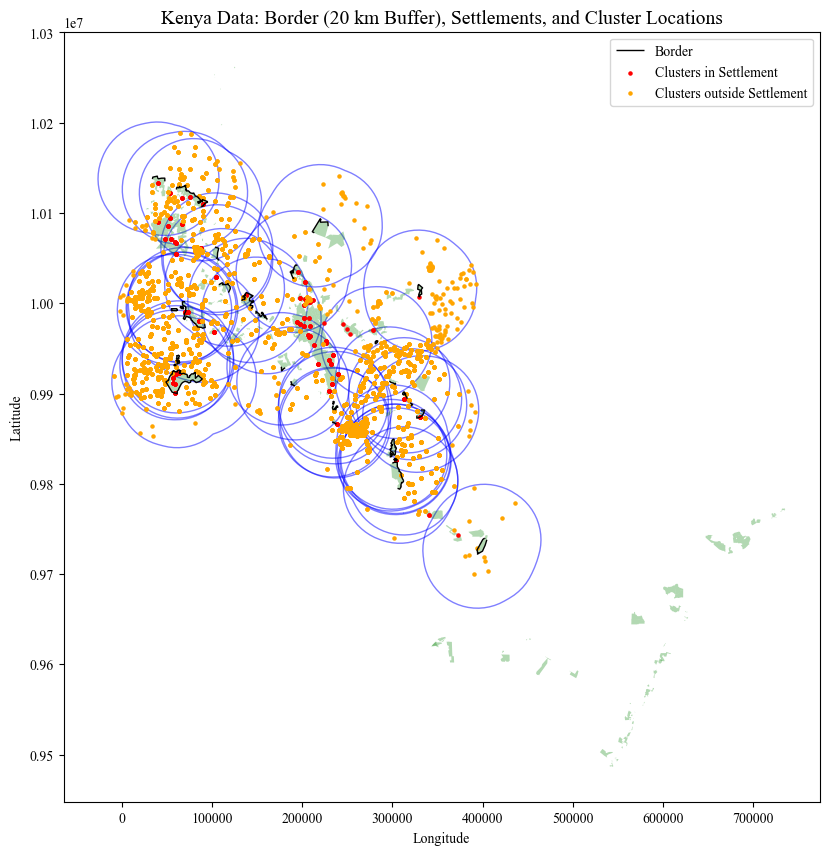

In [56]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# 1. LOAD THE DATA
# ---------------------------------------------------------------------

# 1.1 Load the border shapefile
#orginal
border_shapefile = gpd.read_file(
    "/Users/huiyu/Downloads/full_border_draft_manual/full_border_test1.shp"
)
# #new
# border_shapefile = gpd.read_file(
#     "/Users/huiyu/Downloads/full_border_test1_updated/full_border_test1.shp"
# )

# 1.2 Load the settlement (polygon) shapefile
settlement_shapefile_path = "/Users/huiyu/Downloads/2222/MergedFeatures.shp"
settlement_data = gpd.read_file(settlement_shapefile_path)

# 1.3 Load the household cluster shapefile
cluster_shapefile_path = "/Users/huiyu/Documents/uchicago/kenya project/data/KE_2014_DHS_01162025_51_218744/KEGE71FL/KEGE71FL.shp"
data_cluster = gpd.read_file(cluster_shapefile_path)

# ---------------------------------------------------------------------
# 2. PROJECT DATA INTO A SUITABLE METER-BASED CRS FOR KENYA
#    We'll use EPSG:32737 (WGS 84 / UTM zone 37S).
# ---------------------------------------------------------------------

desired_crs = "EPSG:32737"

border_projected = border_shapefile.to_crs(desired_crs)
settlement_projected = settlement_data.to_crs(desired_crs)
cluster_projected = data_cluster.to_crs(desired_crs)


# ---------------------------------------------------------------------
# 2.1 LOAD MARKET DATA AND COMPUTE DISTANCE TO NEAREST MARKET
# ---------------------------------------------------------------------

# Load the market data
market_data = pd.read_excel("/Users/huiyu/Downloads/Markets.xlsx")  # Adjust path if needed

# Create GeoDataFrame for markets
market_gdf = gpd.GeoDataFrame(
    market_data,
    geometry=gpd.points_from_xy(market_data['GPS Longitude'], market_data['GPS Latitude']),
    crs="EPSG:4326"  # Original CRS (longitude/latitude)
)

# Project markets to the same CRS as the cluster data
market_projected = market_gdf.to_crs(desired_crs)

# Project cluster data (if not already projected)
cluster_projected = data_cluster.to_crs(desired_crs)

# Import nearest points function
from shapely.ops import nearest_points

# Define a function to calculate distance from a point to the nearest market
def nearest_market_distance(point, markets):
    nearest_geom = nearest_points(point, markets.unary_union)[1]
    return point.distance(nearest_geom)

# Apply the function: for each cluster point, find its nearest market
cluster_projected["distance_to_nearest_market"] = cluster_projected.geometry.apply(
    lambda pt: nearest_market_distance(pt, market_projected)
)

# ---------------------------------------------------------------------
# 3. CREATE 20 KM BUFFER AROUND THE BORDER
# ---------------------------------------------------------------------

# 3.1 Buffer in meters: 20 km = 20,000 m
border_buffer = border_projected.buffer(60000)

# 3.2 Convert the Series to a GeoDataFrame for spatial operations
border_buffer_gdf = gpd.GeoDataFrame(geometry=border_buffer, crs=desired_crs)

# ---------------------------------------------------------------------
# 4. FIND ALL CLUSTERS WITHIN THE 20 KM BUFFER
# ---------------------------------------------------------------------

clusters_in_20km = gpd.sjoin(
    cluster_projected, border_buffer_gdf, how="inner", predicate="intersects"
)

# ---------------------------------------------------------------------
# 5. WITHIN THOSE CLUSTERS, FIND WHICH ARE INSIDE/OUTSIDE THE SETTLEMENT POLYGONS
# ---------------------------------------------------------------------

# ----- Fix: drop the join-index columns -----
clusters_in_20km = clusters_in_20km.drop(columns=["index_left", "index_right"], errors="ignore")

# 5.1 Clusters within the polygons
clusters_in_20km_in_settlement = gpd.sjoin(
    clusters_in_20km, settlement_projected, how="inner", predicate="within"
)

# 5.2 Clusters outside the polygons (but still within the 20 km buffer)
clusters_in_20km_out_settlement = clusters_in_20km[
    ~clusters_in_20km.index.isin(clusters_in_20km_in_settlement.index)
]

# ---------------------------------------------------------------------
# 6. PRINT SIMPLE COUNTS
# ---------------------------------------------------------------------
print("Total clusters in the 20 km buffer:", len(clusters_in_20km))
print("    ├─ Clusters inside settlement polygons (in 20 km):", len(clusters_in_20km_in_settlement))
print("    └─ Clusters outside settlement polygons (in 20 km):", len(clusters_in_20km_out_settlement))

# ---------------------------------------------------------------------
# 7. PLOT ALL LAYERS ON A SINGLE FIGURE
# ---------------------------------------------------------------------
import matplotlib as mpl

# 2. Set font globally to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(10, 10))

# 7.1 Plot the original border
border_projected.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, label='Border')

# 7.2 Plot the 20 km buffer
border_buffer_gdf.plot(ax=ax, edgecolor='blue', facecolor='none', alpha=0.5, label='20 km Buffer')

# 7.3 Plot the settlement polygons
settlement_projected.plot(ax=ax, color='green', alpha=0.3, label='Settlement Polygons')

# 7.4 Plot the clusters within 20 km & in settlement polygons
clusters_in_20km_in_settlement.plot(ax=ax, color='red', markersize=5, label='Clusters in Settlement')

# 7.5 Plot the clusters within 20 km & outside settlement polygons
clusters_in_20km_out_settlement.plot(ax=ax, color='orange', markersize=5, label='Clusters outside Settlement')

# 7.6 Customize and show the plot
# ax.set_title("Kenya Data: Border (20 km Buffer), Settlements, and Cluster Locations (UTM 37S)")
ax.set_title("Kenya Data: Border (20 km Buffer), Settlements, and Cluster Locations", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.legend()
plt.show()


/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_60153/1458833025.py:30: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler


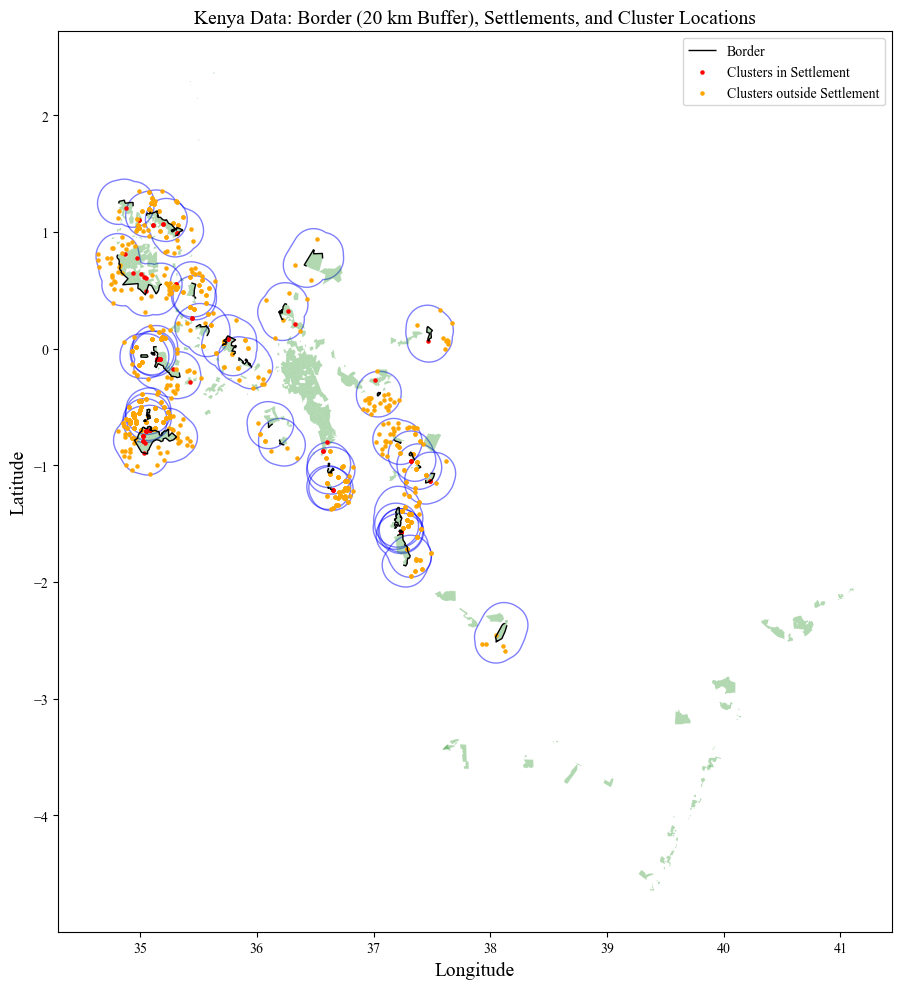

In [43]:
# Reproject all data to longitude-latitude (WGS84)
border_wgs = border_projected.to_crs(epsg=4326)
buffer_wgs = border_buffer_gdf.to_crs(epsg=4326)
settlement_wgs = settlement_projected.to_crs(epsg=4326)
clusters_in_20km_in_settlement_wgs = clusters_in_20km_in_settlement.to_crs(epsg=4326)
clusters_in_20km_out_settlement_wgs = clusters_in_20km_out_settlement.to_crs(epsg=4326)

import matplotlib.pyplot as plt
import matplotlib as mpl

# Set font to Times New Roman
mpl.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(10, 10))

# Plot each layer using the reprojected (lon-lat) data
border_wgs.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, label='Border')
buffer_wgs.plot(ax=ax, edgecolor='blue', facecolor='none', alpha=0.5, label='20 km Buffer')
settlement_wgs.plot(ax=ax, color='green', alpha=0.3, label='Settlement Polygons')
clusters_in_20km_in_settlement_wgs.plot(ax=ax, color='red', markersize=5, label='Clusters in Settlement')
clusters_in_20km_out_settlement_wgs.plot(ax=ax, color='orange', markersize=5, label='Clusters outside Settlement')

# Set axis labels and title in correct units
ax.set_title("Kenya Data: Border (20 km Buffer), Settlements, and Cluster Locations", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlabel("Longitude", fontsize=14)
ax.set_ylabel("Latitude", fontsize=14)

plt.legend()
plt.tight_layout()
plt.show()


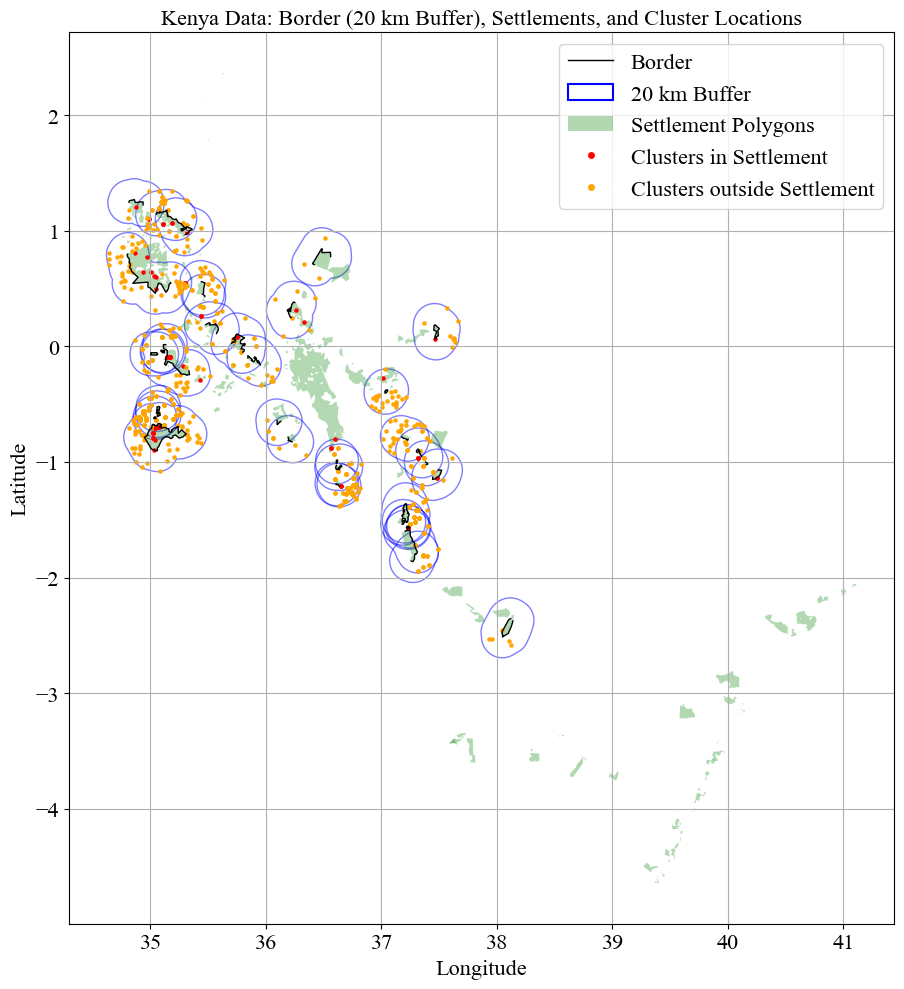

In [57]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# Set global font
mpl.rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize=(10, 10))

# Plot the layers (note: we don't rely on label= inside plot)
border_wgs.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1)
buffer_wgs.plot(ax=ax, edgecolor='blue', facecolor='none', alpha=0.5)
settlement_wgs.plot(ax=ax, color='green', alpha=0.3)
clusters_in_20km_in_settlement_wgs.plot(ax=ax, color='red', markersize=5)
clusters_in_20km_out_settlement_wgs.plot(ax=ax, color='orange', markersize=5)

# Set axis labels and tick font size
ax.set_title("Kenya Data: Border (20 km Buffer), Settlements, and Cluster Locations", fontsize=16)
ax.set_xlabel("Longitude", fontsize=16)
ax.set_ylabel("Latitude", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=16)

# Manually define legend handles
legend_elements = [
    Line2D([0], [0], color='black', lw=1, label='Border'),
    Patch(edgecolor='blue', facecolor='none', linewidth=1.5, label='20 km Buffer'),
    Patch(facecolor='green', edgecolor='none', alpha=0.3, label='Settlement Polygons'),
    Line2D([0], [0], marker='o', color='w', label='Clusters in Settlement',
           markerfacecolor='red', markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Clusters outside Settlement',
           markerfacecolor='orange', markersize=6)
]

# Add legend
ax.legend(handles=legend_elements, fontsize=16, loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()


In [58]:

# 1. Compute the unified border geometry (single shape)
# ---------------------------------------------------------------------
border_union = border_projected.unary_union

# ---------------------------------------------------------------------
# 2. Add distance-to-border (in meters) for "in settlement" clusters
# ---------------------------------------------------------------------
clusters_in_20km_in_settlement["dist_to_border_m"] = (
    clusters_in_20km_in_settlement.geometry.distance(border_union)
)

# ---------------------------------------------------------------------
# 3. Add distance-to-border (in meters) for "out settlement" clusters
# ---------------------------------------------------------------------
clusters_in_20km_out_settlement["dist_to_border_m"] = (
    clusters_in_20km_out_settlement.geometry.distance(border_union)
)

# ---------------------------------------------------------------------
# 4. Preview the results
# ---------------------------------------------------------------------
print("\nClusters in settlement (distance to border, first 5 rows):")
print(clusters_in_20km_in_settlement[["geometry", "dist_to_border_m"]].head())

print("\nClusters out settlement (distance to border, first 5 rows):")
print(clusters_in_20km_out_settlement[["geometry", "dist_to_border_m"]].head())


Clusters in settlement (distance to border, first 5 rows):
                           geometry  dist_to_border_m
56   POINT (224486.904 9978009.286)      59875.142353
59  POINT (212371.254 10003286.659)      32345.952888
59  POINT (212371.254 10003286.659)      32345.952888
61   POINT (202155.020 9983519.566)      41029.322373
61   POINT (202155.020 9983519.566)      41029.322373

Clusters out settlement (distance to border, first 5 rows):
                         geometry  dist_to_border_m
0  POINT (249958.251 9858110.527)      14683.897089
0  POINT (249958.251 9858110.527)      14683.897089
0  POINT (249958.251 9858110.527)      14683.897089
0  POINT (249958.251 9858110.527)      14683.897089
0  POINT (249958.251 9858110.527)      14683.897089


/Users/huiyu/opt/anaconda3/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [59]:
clusters_in_20km_in_settlement=clusters_in_20km_in_settlement.drop_duplicates()
clusters_in_20km_out_settlement=clusters_in_20km_out_settlement.drop_duplicates()
clusters_in_20km_in_settlement["within_settlement"] =1
clusters_in_20km_out_settlement["within_settlement"] = 0

cluster_points = gpd.pd.concat(
    [clusters_in_20km_in_settlement, clusters_in_20km_out_settlement],
    ignore_index=True
)
median_distance = cluster_points["distance_to_nearest_market"].median()
print(f"The median distance to nearest market is {median_distance:.2f} meters.")
# Step 2: Create the new column based on the median
cluster_points["market_distance_above_median"] = cluster_points["distance_to_nearest_market"].apply(
    lambda x: 0 if x > median_distance else 1
)

The median distance to nearest market is 4095.37 meters.


/Users/huiyu/opt/anaconda3/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
/Users/huiyu/opt/anaconda3/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [60]:
# match geo cov : test weather and sol
import pandas as pd
### geo cov data: 
# Assuming `geo_cov` and `cluster_data_combined` DataFrames are loaded
geo_cov=pd.read_csv("/Users/huiyu/Documents/uchicago/kenya project/data/KE_2022_DHS_09262024_2355_218744/KEGC8AFL/KEGC8AFL.csv")
# Merge the two DataFrames based on the 'DHSCLUST' column
cluster_points_withgeo = pd.merge(cluster_points, geo_cov, on='DHSCLUST', how='left')

### 1.4.1 women 2014 -edu

In [61]:
#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2014_DHS_10032024_1837_218744/KEIR72DT/KEIR72FL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'v001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')

In [62]:
# if is within the settlement area, the distance is positive, otherwise negative
household_geo.loc[
    household_geo["within_settlement"] == 1, 
    "dist_to_border_m"
] *= -1

In [79]:
# # 导出 方便r操作
# household_geo.to_csv("/Users/huiyu/Downloads/household_geo_women_2014.csv")

#### balance table for women feature

In [63]:
#educ balance table 2022
from scipy import stats
import pandas as pd

# Define the columns for which we want to calculate the p-values
#v012- age,v131-ethnics, v149 eudcation att， v106: higher education level, v107 hihest year of education, v438 height,v190a:wealth index for urbn/rural
# v131:ethnicity, v438:responendent height , hw3_1:child height , v745b:own land or jointly
#sreduc:respondent education, 

# for the household dataset, the education- hv105; ag- ; wealthindex -hv270 ; chid height-hc3 ; own land -hv244(use land for agroculture)/sh118_b  ;
# ethnicitcity ; responsdent height -ha3; hv009- number of family numbers; hv011- number of eligible men' hv010: number of eligible women
# 还差ethinicity
# v131 改造, 前五名的种族分别是kikuya- 3; kalenjin- 1; luhya- 5; luo-6; kamba-2; somali-10 
# 
# Create binary indicator variables based on v131 ethnicity codes
household_geo["kalenjin"] = (household_geo["v131"] == 2).astype(int)
household_geo["kikuyu"]   = (household_geo["v131"] == 4).astype(int)
household_geo["kamba"]    = (household_geo["v131"] == 3).astype(int)
household_geo["luhya"]    = (household_geo["v131"] == 6).astype(int)
household_geo["luo"]      = (household_geo["v131"] == 7).astype(int)
household_geo["somali"]   = (household_geo["v131"] == 11).astype(int)


variables = ["v131","v149","v107","v190",'v106','v012','v131',"v438","hw3_1","v745b","kalenjin","kikuyu","kamba","luhya","luo"]

# Create an empty DataFrame to store mean values and p-values
mean_values = pd.DataFrame(columns=['Inside', 'Outside', 'p-value'], index=variables)

# Calculate mean values and p-values for each variable
for var in variables:
    inside_values = household_geo[household_geo['within_settlement'] == 1][var]
    outside_values = household_geo[household_geo['within_settlement'] == 0][var]
    
    # Calculate mean for 'Inside' and 'Outside'
    mean_values.at[var, 'Inside'] = inside_values.mean()
    mean_values.at[var, 'Outside'] = outside_values.mean()
    
    # Perform t-test and store the p-value
    t_stat, p_value = stats.ttest_ind(inside_values, outside_values, nan_policy='omit')
    mean_values.at[var, 'p-value'] = p_value

# Display the table
print(mean_values)
mean_values.to_csv("/Users/huiyu/Documents/uchicago/kenya project/data/var_v1_20km.csv")



               Inside      Outside   p-value
v131         4.520292     5.564712  0.000006
v149         2.546266     2.436636  0.008331
v107          5.06874     4.965261  0.163968
v190         3.237013     3.151806  0.031754
v106         1.530032     1.485993  0.044826
v012        30.323052    29.146524  0.000023
v131         4.520292     5.564712  0.000006
v438      1631.359511  1680.644634  0.159277
hw3_1      885.515094   910.797423  0.559048
v745b        0.888696     0.812015  0.072045
kalenjin     0.126623     0.216104       0.0
kikuyu       0.512987      0.21477       0.0
kamba        0.075487     0.106078  0.000662
luhya        0.131494      0.11723  0.132933
luo          0.046266     0.086602  0.000001


In [118]:
print("within household member number: ",len(household_geo[household_geo['within_settlement'] == 1]))
print("outside household member number: ",len(household_geo[household_geo['within_settlement'] == 0]))


within household member number:  527
outside household member number:  7115


In [74]:
household_geo[household_geo["v131"]==1]

,caseid,v000,DHSCLUST,v002,v003,v004,v005,v006,v007,v008,...,Wet_Days_2005,Wet_Days_2010,Wet_Days_2015,Wet_Days_2020,kalenjin,kikuyu,kamba,luhya,luo,somali
34,0003011 02,KE6,3,11,2,3,4492163,8,2014,1376,...,8.749036,8.979206,11.635752,11.781808,0,0,0,0,0,0
183,0013023 02,KE6,13,23,2,13,2607059,5,2014,1373,...,NaN,NaN,NaN,NaN,0,0,0,0,0,0
186,0013035 02,KE6,13,35,2,13,2607059,5,2014,1373,...,NaN,NaN,NaN,NaN,0,0,0,0,0,0
486,0029051 01,KE6,29,51,1,29,3399401,6,2014,1374,...,NaN,NaN,NaN,NaN,0,0,0,0,0,0
526,0031111 02,KE6,31,111,2,31,3268195,7,2014,1375,...,NaN,NaN,NaN,NaN,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21854,1158062 01,KE6,1158,62,1,1158,475358,9,2014,1377,...,NaN,NaN,NaN,NaN,0,0,0,0,0,0
24382,1283087 02,KE6,1283,87,2,1283,630570,6,2014,1374,...,NaN,NaN,NaN,NaN,0,0,0,0,0,0
24389,1284029 02,KE6,1284,29,2,1284,403932,7,2014,1375,...,NaN,NaN,NaN,NaN,0,0,0,0,0,0
27100,1420011 01,KE6,1420,11,1,1420,899415,6,2014,1374,...,13.527448,18.633306,16.034231,19.249126,0,0,0,0,0,0


In [132]:
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["v107", "dist_to_border_m", "v012", "v151", "v005","kalenjin","kikuyu","luhya","luo","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["v005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v107 ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012+popu+ kalenjin+ kikuyu+luhya+luo+kamba "

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                   v107   R-squared:                       0.034
Model:                            WLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     56.35
Date:                Fri, 02 May 2025   Prob (F-statistic):          1.64e-134
Time:                        21:09:28   Log-Likelihood:                -46857.
No. Observations:               19012   AIC:                         9.374e+04
Df Residuals:                   18999   BIC:                         9.384e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.9928      0.095     41.926   

#### rdrobust

In [64]:
import pandas as pd
import numpy as np
import rdrobust  # make sure rdrobust is installed

# 1. Drop missing values
household_geo = household_geo.dropna(
    subset=["v107", "dist_to_border_m", "v012", "v151", "v005", 
            "kalenjin", "kikuyu", "luhya", "luo", "kamba", "UN_Population_Count_2020"]
)

# 2. Define key variables
y = household_geo["v107"].to_numpy()
x = household_geo["dist_to_border_m"].to_numpy()
covs = household_geo[["v012", "v151", "UN_Population_Count_2020", 
                      "kalenjin", "kikuyu", "luhya", "luo", "kamba"]].to_numpy()
weights = household_geo["v005"].to_numpy() / 1_000_000

# 3. Run rdrobust with controls and weights
result = rdrobust.rdrobust(y=y, x=x, covs=covs, weights=weights, p=2, bwselect='msetwo')

# 4. Print results
print(result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                 19012
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations          1222      17790
Number of Unique Obs.             66        952
Number of Effective Obs.         500       5907
Bandwidth Estimation       14065.331  17321.171
Bandwidth Bias             19174.186  23493.075
rho (h/b)                      0.734      0.737

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.746     0.29    2.569   1.019e-02     [0.177, 1.315]
Robust     

/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_60153/2069255627.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


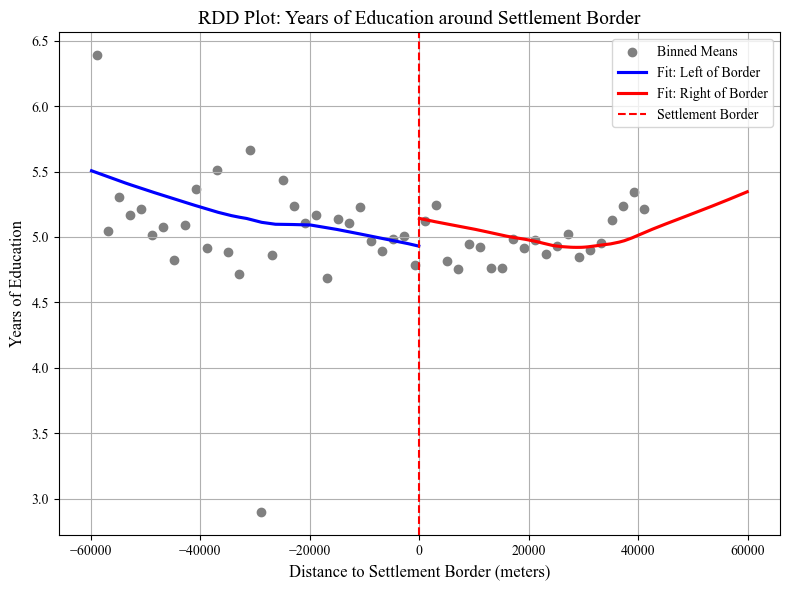

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define the running variable and outcome
x = household_geo["dist_to_border_m"].to_numpy()
y = household_geo["v107"].to_numpy()  # <-- updated to v107 (Years of Education)

# Bin the data
bin_width = 2000  # in meters
bins = np.arange(x.min(), x.max(), bin_width)
df = pd.DataFrame({'x': x, 'y': y})
df = df.dropna()  # drop any potential NA values
df['x_binned'] = pd.cut(df['x'], bins)
bin_means = df.groupby('x_binned').mean().dropna()

# Midpoints for bins
bin_midpoints = bins[:-1] + bin_width / 2
bin_means['bin_mid'] = bin_midpoints[:len(bin_means)]

# Separate left and right of the cutoff
left = df['x'] < 0
right = df['x'] >= 0

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot: binned means
ax.scatter(bin_means['bin_mid'], bin_means['y'], color='gray', label='Binned Means')

# Fit curves using LOWESS
sns.regplot(x=df[left]['x'], y=df[left]['y'], lowess=True, scatter=False, label='Fit: Left of Border', color='blue', ax=ax)
sns.regplot(x=df[right]['x'], y=df[right]['y'], lowess=True, scatter=False, label='Fit: Right of Border', color='red', ax=ax)

# Add cutoff line
ax.axvline(x=0, color='red', linestyle='--', label='Settlement Border')

# Labels and formatting
ax.set_xlabel("Distance to Settlement Border (meters)", fontsize=12)
ax.set_ylabel("Years of Education", fontsize=12)
ax.set_title("RDD Plot: Years of Education around Settlement Border", fontsize=14)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_60153/3363960670.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


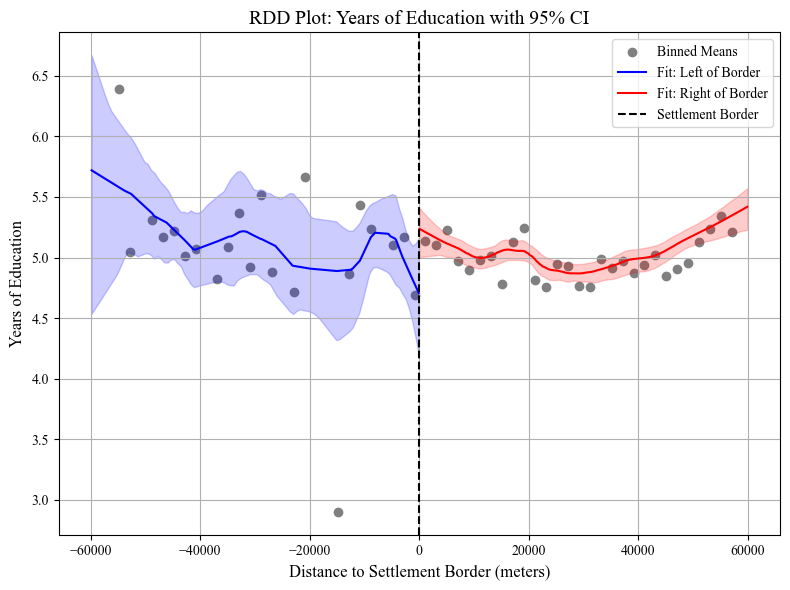

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# Prepare data
x = household_geo["dist_to_border_m"].to_numpy()
y = household_geo["v107"].to_numpy()
df = pd.DataFrame({'x': x, 'y': y}).dropna()

# Bin means
bin_width = 2000
bins = np.arange(df['x'].min(), df['x'].max(), bin_width)
df['x_binned'] = pd.cut(df['x'], bins)
bin_means = df.groupby('x_binned').mean().dropna()
# Map bin midpoints only for bins that actually exist in bin_means
bin_labels = df['x_binned'].cat.categories
bin_centers = bins[:-1] + bin_width / 2
label_to_center = dict(zip(bin_labels, bin_centers))
bin_means['bin_mid'] = bin_means.index.map(label_to_center)


# Split left and right
df_left = df[df['x'] < 0]
df_right = df[df['x'] >= 0]

# LOWESS fit
lowess_left = lowess(df_left['y'], df_left['x'], frac=0.3, return_sorted=True)
lowess_right = lowess(df_right['y'], df_right['x'], frac=0.3, return_sorted=True)

# Bootstrap CI function
def bootstrap_ci(data, x_col, y_col, frac=0.3, n_bootstrap=100):
    x_vals = np.linspace(data[x_col].min(), data[x_col].max(), 100)
    y_boots = np.zeros((n_bootstrap, len(x_vals)))
    for i in range(n_bootstrap):
        sample = data.sample(frac=1, replace=True)
        fit = lowess(sample[y_col], sample[x_col], frac=frac, return_sorted=False)
        interp = np.interp(x_vals, np.sort(sample[x_col]), fit[np.argsort(sample[x_col])])
        y_boots[i, :] = interp
    lower = np.percentile(y_boots, 2.5, axis=0)
    upper = np.percentile(y_boots, 97.5, axis=0)
    return x_vals, lower, upper

# Compute bootstrapped CI
x_l, y_l, y_u = bootstrap_ci(df_left, 'x', 'y')
x_r, y_l_r, y_u_r = bootstrap_ci(df_right, 'x', 'y')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Binned means
ax.scatter(bin_means['bin_mid'], bin_means['y'], color='gray', label='Binned Means')

# LOWESS line + CI left
ax.plot(lowess_left[:, 0], lowess_left[:, 1], color='blue', label='Fit: Left of Border')
ax.fill_between(x_l, y_l, y_u, color='blue', alpha=0.2)

# LOWESS line + CI right
ax.plot(lowess_right[:, 0], lowess_right[:, 1], color='red', label='Fit: Right of Border')
ax.fill_between(x_r, y_l_r, y_u_r, color='red', alpha=0.2)

# Border line
ax.axvline(x=0, color='black', linestyle='--', label='Settlement Border')

# Labels
ax.set_xlabel("Distance to Settlement Border (meters)", fontsize=12)
ax.set_ylabel("Years of Education", fontsize=12)
ax.set_title("RDD Plot: Years of Education with 95% CI", fontsize=14)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


### 1.4.2 women 2014 -wealth

In [123]:
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["v107", "dist_to_border_m", "v012", "v151", "v005","kalenjin","kikuyu","luhya","luo","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["v005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v190 ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012 +popu+ kalenjin+ kikuyu+luhya+luo+kamba"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                   v190   R-squared:                       0.192
Model:                            WLS   Adj. R-squared:                  0.192
Method:                 Least Squares   F-statistic:                     395.5
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        20:53:29   Log-Likelihood:                -34116.
No. Observations:               19940   AIC:                         6.826e+04
Df Residuals:                   19927   BIC:                         6.836e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.4727      0.044     78.654   

/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_60153/3773758902.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


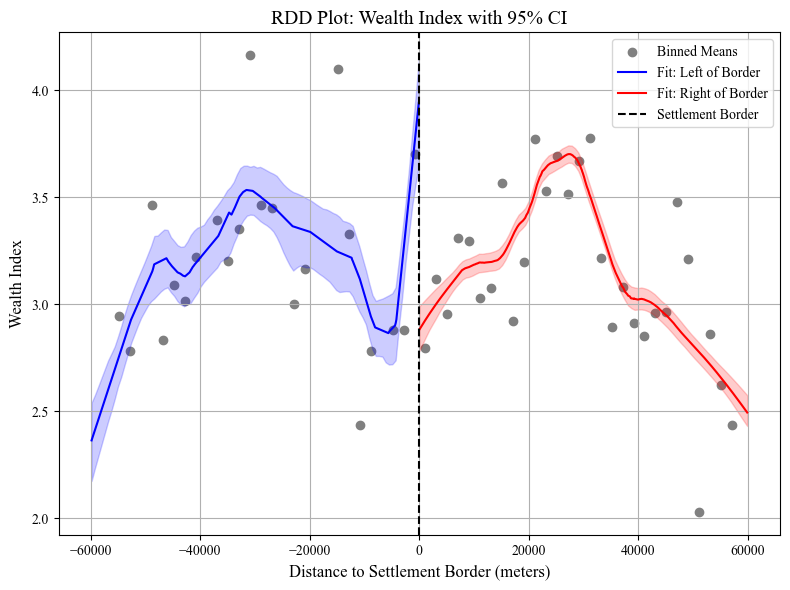

In [79]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# Prepare data
x = household_geo["dist_to_border_m"].to_numpy()
y = household_geo["v190"].to_numpy()
df = pd.DataFrame({'x': x, 'y': y}).dropna()

# Bin means
bin_width = 2000
bins = np.arange(df['x'].min(), df['x'].max(), bin_width)
df['x_binned'] = pd.cut(df['x'], bins)
bin_means = df.groupby('x_binned').mean().dropna()
# Map bin midpoints only for bins that actually exist in bin_means
bin_labels = df['x_binned'].cat.categories
bin_centers = bins[:-1] + bin_width / 2
label_to_center = dict(zip(bin_labels, bin_centers))
bin_means['bin_mid'] = bin_means.index.map(label_to_center)


# Split left and right
df_left = df[df['x'] < 0]
df_right = df[df['x'] >= 0]

# LOWESS fit
lowess_left = lowess(df_left['y'], df_left['x'], frac=0.3, return_sorted=True)
lowess_right = lowess(df_right['y'], df_right['x'], frac=0.3, return_sorted=True)

# Bootstrap CI function
def bootstrap_ci(data, x_col, y_col, frac=0.3, n_bootstrap=100):
    x_vals = np.linspace(data[x_col].min(), data[x_col].max(), 100)
    y_boots = np.zeros((n_bootstrap, len(x_vals)))
    for i in range(n_bootstrap):
        sample = data.sample(frac=1, replace=True)
        fit = lowess(sample[y_col], sample[x_col], frac=frac, return_sorted=False)
        interp = np.interp(x_vals, np.sort(sample[x_col]), fit[np.argsort(sample[x_col])])
        y_boots[i, :] = interp
    lower = np.percentile(y_boots, 2.5, axis=0)
    upper = np.percentile(y_boots, 97.5, axis=0)
    return x_vals, lower, upper

# Compute bootstrapped CI
x_l, y_l, y_u = bootstrap_ci(df_left, 'x', 'y')
x_r, y_l_r, y_u_r = bootstrap_ci(df_right, 'x', 'y')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Binned means
ax.scatter(bin_means['bin_mid'], bin_means['y'], color='gray', label='Binned Means')

# LOWESS line + CI left
ax.plot(lowess_left[:, 0], lowess_left[:, 1], color='blue', label='Fit: Left of Border')
ax.fill_between(x_l, y_l, y_u, color='blue', alpha=0.2)

# LOWESS line + CI right
ax.plot(lowess_right[:, 0], lowess_right[:, 1], color='red', label='Fit: Right of Border')
ax.fill_between(x_r, y_l_r, y_u_r, color='red', alpha=0.2)

# Border line
ax.axvline(x=0, color='black', linestyle='--', label='Settlement Border')

# Labels
ax.set_xlabel("Distance to Settlement Border (meters)", fontsize=12)
ax.set_ylabel("Wealth Index", fontsize=12)
ax.set_title("RDD Plot: Wealth Index with 95% CI", fontsize=14)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


#### rdrobust

In [124]:
import pandas as pd
import numpy as np
import rdrobust  # make sure rdrobust is installed

# 1. Drop missing values
household_geo = household_geo.dropna(
    subset=["v190", "dist_to_border_m", "v012", "v151", "v005", 
            "kalenjin", "kikuyu", "luhya", "luo", "kamba", "UN_Population_Count_2020"]
)

# 2. Define key variables
y = household_geo["v190"].to_numpy()
x = household_geo["dist_to_border_m"].to_numpy()
covs = household_geo[["v012", "v151", "UN_Population_Count_2020", 
                      "kalenjin", "kikuyu", "luhya", "luo", "kamba"]].to_numpy()
weights = household_geo["v005"].to_numpy() / 1_000_000

# 3. Run rdrobust with controls and weights
result = rdrobust.rdrobust(y=y, x=x, covs=covs, weights=weights, p=2, bwselect='msetwo')

# 4. Print results
print(result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                 19940
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations          1222      18718
Number of Unique Obs.             66        996
Number of Effective Obs.         516       3115
Bandwidth Estimation        9434.262   9692.276
Bandwidth Bias             13101.414  16150.475
rho (h/b)                       0.72        0.6

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -1.189    0.108  -11.029   2.760e-28   [-1.401, -0.978]
Robust     

/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_60153/433120785.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


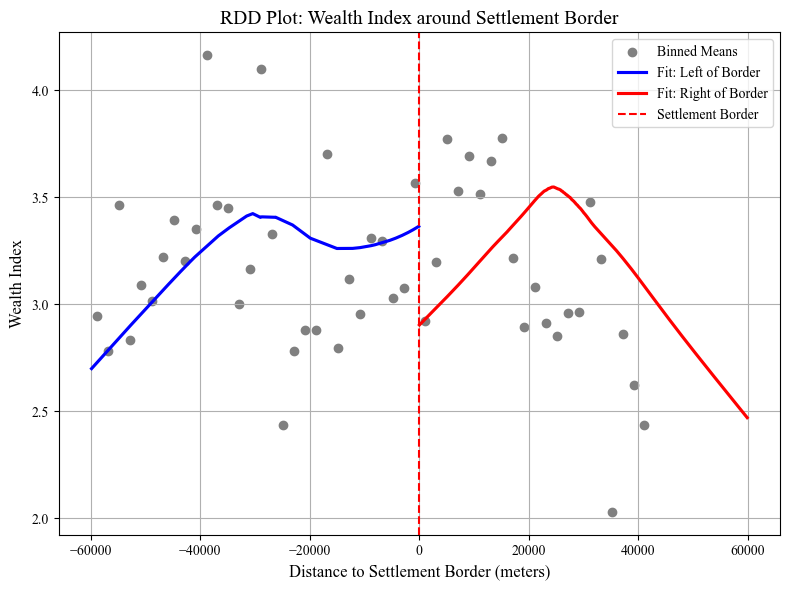

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Define the running variable and outcome
x = household_geo["dist_to_border_m"].to_numpy()
y = household_geo["v190"].to_numpy()  # <-- updated to v107 (Years of Education)

# Bin the data
bin_width = 2000  # in meters
bins = np.arange(x.min(), x.max(), bin_width)
df = pd.DataFrame({'x': x, 'y': y})
df = df.dropna()  # drop any potential NA values
df['x_binned'] = pd.cut(df['x'], bins)
bin_means = df.groupby('x_binned').mean().dropna()

# Midpoints for bins
bin_midpoints = bins[:-1] + bin_width / 2
bin_means['bin_mid'] = bin_midpoints[:len(bin_means)]

# Separate left and right of the cutoff
left = df['x'] < 0
right = df['x'] >= 0

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Scatter plot: binned means
ax.scatter(bin_means['bin_mid'], bin_means['y'], color='gray', label='Binned Means')

# Fit curves using LOWESS
sns.regplot(x=df[left]['x'], y=df[left]['y'], lowess=True, scatter=False, label='Fit: Left of Border', color='blue', ax=ax)
sns.regplot(x=df[right]['x'], y=df[right]['y'], lowess=True, scatter=False, label='Fit: Right of Border', color='red', ax=ax)

# Add cutoff line
ax.axvline(x=0, color='red', linestyle='--', label='Settlement Border')

# Labels and formatting
ax.set_xlabel("Distance to Settlement Border (meters)", fontsize=12)
ax.set_ylabel("Wealth Index", fontsize=12)
ax.set_title("RDD Plot: Wealth Index around Settlement Border", fontsize=14)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


### 1.4.3  women 2014 - market

In [54]:
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
# far
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["v107", "dist_to_border_m", "v012", "v151", "v005","kalenjin","kikuyu","luhya","luo","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["v005"] / 1_000_000

household_geo1["popu"] = household_geo1["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v107 ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012 +popu+ kalenjin+ kikuyu+luhya+luo+kamba"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                   v107   R-squared:                       0.030
Model:                            WLS   Adj. R-squared:                  0.027
Method:                 Least Squares   F-statistic:                     10.90
Date:                Fri, 02 May 2025   Prob (F-statistic):           9.94e-22
Time:                        20:22:28   Log-Likelihood:                -10488.
No. Observations:                4314   AIC:                         2.100e+04
Df Residuals:                    4301   BIC:                         2.108e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.5139      0.202     22.297   

In [135]:
import pandas as pd
import numpy as np
import rdrobust  # make sure rdrobust is installed
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]

# 1. Drop missing values
household_geo1 = household_geo1.dropna(
    subset=["v107", "dist_to_border_m", "v012", "v151", "v005", 
            "kalenjin", "kikuyu", "luhya", "luo", "kamba", "UN_Population_Count_2020"]
)

# 2. Define key variables
y = household_geo1["v107"].to_numpy()
x = household_geo1["dist_to_border_m"].to_numpy()
covs = household_geo1[["v012", "v151", "UN_Population_Count_2020", 
                      "kalenjin", "kikuyu", "luhya", "luo", "kamba"]].to_numpy()
weights = household_geo1["v005"].to_numpy() / 1_000_000

# 3. Run rdrobust with controls and weights
result = rdrobust.rdrobust(y=y, x=x, covs=covs, weights=weights, p=2, bwselect='msetwo')

# 4. Print results
print(result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                  9445
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           820       8625
Number of Unique Obs.             44        464
Number of Effective Obs.         346       2966
Bandwidth Estimation        22875.73  18172.004
Bandwidth Bias             30499.139   26739.72
rho (h/b)                       0.75       0.68

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional        1.26    0.339    3.714   2.044e-04     [0.595, 1.925]
Robust     

In [55]:
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
# far
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 1]
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["v107", "dist_to_border_m", "v012", "v151", "v005","kalenjin","kikuyu","luhya","luo","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["v005"] / 1_000_000

household_geo1["popu"] = household_geo1["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v107 ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012 +popu+ kalenjin+ kikuyu+luhya+luo+kamba"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                   v107   R-squared:                       0.039
Model:                            WLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     14.24
Date:                Fri, 02 May 2025   Prob (F-statistic):           1.40e-29
Time:                        20:22:39   Log-Likelihood:                -10395.
No. Observations:                4236   AIC:                         2.082e+04
Df Residuals:                    4223   BIC:                         2.090e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.4377      0.237     14.484   

In [41]:
import pandas as pd
import numpy as np
import rdrobust  # make sure rdrobust is installed
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 1]

# 1. Drop missing values
household_geo1 = household_geo1.dropna(
    subset=["v107", "dist_to_border_m", "v012", "v151", "v005", 
            "kalenjin", "kikuyu", "luhya", "luo", "kamba", "UN_Population_Count_2020"]
)

# 2. Define key variables
y = household_geo1["v107"].to_numpy()
x = household_geo1["dist_to_border_m"].to_numpy()
covs = household_geo1[["v012", "v151", "UN_Population_Count_2020", 
                      "kalenjin", "kikuyu", "luhya", "luo", "kamba"]].to_numpy()
weights = household_geo1["v005"].to_numpy() / 1_000_000

# 3. Run rdrobust with controls and weights
result = rdrobust.rdrobust(y=y, x=x, covs=covs, weights=weights, p=2, bwselect='msetwo')

# 4. Print results
print(result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                  3728
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           176       3552
Number of Unique Obs.             10        183
Number of Effective Obs.          76        667
Bandwidth Estimation        5535.894   5422.027
Bandwidth Bias              8289.917   7980.848
rho (h/b)                      0.668      0.679

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.351    0.867   -0.404   6.859e-01    [-2.051, 1.349]
Robust     

### 1.5.1 men 2014 -edu

In [80]:

#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2014_DHS_10032024_1837_218744/KEMR72DT/KEMR72FL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'mv001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')


In [81]:
# if is within the settlement area, the distance is positive, otherwise negative
household_geo.loc[
    household_geo["within_settlement"] == 1, 
    "dist_to_border_m"
] *= -1

In [ ]:
# 导出 方便r操作
household_geo.to_csv("/Users/huiyu/Downloads/household_geo_men_2014.csv")

#### balance table men

In [138]:
#educ balance table 2022
from scipy import stats
import pandas as pd

# Define the columns for which we want to calculate the p-values
#v012- age,v131-ethnics, v149 eudcation att， v106: higher education level, v107 hihest year of education, v438 height,v190a:wealth index for urbn/rural
# v131:ethnicity, v438:responendent height , hw3_1:child height , v745b:own land or jointly
#sreduc:respondent education, 

# for the household dataset, the education- hv105; ag- ; wealthindex -hv270 ; chid height-hc3 ; own land -hv244(use land for agroculture)/sh118_b  ;
# ethnicitcity ; responsdent height -ha3; hv009- number of family numbers; hv011- number of eligible men' hv010: number of eligible women
# 还差ethinicity
# v131 改造, 前五名的种族分别是kikuya- 3; kalenjin- 1; luhya- 5; luo-6; kamba-2; somali-10 
# 
# Create binary indicator variables based on v131 ethnicity codes
household_geo["kalenjin"] = (household_geo["mv131"] == 2).astype(int)
household_geo["kikuyu"]   = (household_geo["mv131"] == 4).astype(int)
household_geo["kamba"]    = (household_geo["mv131"] == 3).astype(int)
household_geo["luhya"]    = (household_geo["mv131"] == 6).astype(int)
household_geo["luo"]      = (household_geo["mv131"] == 7).astype(int)
household_geo["somali"]   = (household_geo["mv131"] == 11).astype(int)


variables = ["mv131","mv149","mv107","mv190",'mv106','mv012','mv131',"mv745b","kalenjin","kikuyu","kamba","luhya","luo"]

# Create an empty DataFrame to store mean values and p-values
mean_values = pd.DataFrame(columns=['Inside', 'Outside', 'p-value'], index=variables)

# Calculate mean values and p-values for each variable
for var in variables:
    inside_values = household_geo[household_geo['within_settlement'] == 1][var]
    outside_values = household_geo[household_geo['within_settlement'] == 0][var]
    
    # Calculate mean for 'Inside' and 'Outside'
    mean_values.at[var, 'Inside'] = inside_values.mean()
    mean_values.at[var, 'Outside'] = outside_values.mean()
    
    # Perform t-test and store the p-value
    t_stat, p_value = stats.ttest_ind(inside_values, outside_values, nan_policy='omit')
    mean_values.at[var, 'p-value'] = p_value

# Display the table
print(mean_values)
mean_values.to_csv("/Users/huiyu/Documents/uchicago/kenya project/data/var_v1_20km.csv")



/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_1889/1452427900.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_1889/1452427900.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_1889/1452427900.py:18: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(

            Inside    Outside   p-value
mv131     4.568458   5.419269   0.00557
mv149     2.713793   2.586788  0.038746
mv107     4.785714   4.822499  0.726731
mv190     3.224138   3.120451  0.065057
mv106     1.617241   1.571827  0.152105
mv012     31.22931  30.286294  0.044761
mv131     4.568458   5.419269   0.00557
mv745b     0.57931    0.72454  0.000089
kalenjin  0.143103   0.212628  0.000068
kikuyu    0.482759   0.213896       0.0
kamba     0.082759   0.109928  0.041949
luhya     0.143103   0.128566  0.314374
luo        0.02931   0.079371  0.000011


In [59]:
print("within household member number: ",len(household_geo[household_geo['within_settlement'] == 1]))
print("outside household member number: ",len(household_geo[household_geo['within_settlement'] == 0]))


within household member number:  314
outside household member number:  3481


In [60]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# 1. DROP MISSING VALUES IN KEY VARIABLES
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["mv107", "dist_to_border_m", "mv012", "mv151", "mv005", "UN_Population_Count_2015","kalenjin","kikuyu","kamba","luhya","luo"]
)

# ---------------------------------------------------------
# 2. CREATE THE "TREATMENT" VARIABLE
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. CENTER THE RUNNING VARIABLE AROUND THE CUTOFF
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. CREATE AGE SQUARED (v012^2)
# ---------------------------------------------------------
household_geo["v012_sq"] = household_geo["mv012"] ** 2

# ---------------------------------------------------------
# 5. SCALE SAMPLE WEIGHTS (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["mv005"] / 1_000_000

# ---------------------------------------------------------
# 6. SPECIFY THE WEIGHTED RDD REGRESSION FORMULA
# ---------------------------------------------------------
formula = "mv107 ~ treatment + dist_cent + dist_cent_sq + mv012 + v012_sq + mv151+ UN_Population_Count_2015+ kalenjin+ kikuyu+luhya+luo+kamba"

# ---------------------------------------------------------
# 7. FIT THE MODEL USING WEIGHTED LEAST SQUARES (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. VIEW THE RESULTS
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  mv107   R-squared:                       0.020
Model:                            WLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     6.296
Date:                Fri, 02 May 2025   Prob (F-statistic):           3.83e-11
Time:                        20:22:55   Log-Likelihood:                -9093.7
No. Observations:                3746   AIC:                         1.821e+04
Df Residuals:                    3733   BIC:                         1.829e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

#### rdrobust

In [140]:
import pandas as pd
import numpy as np
import rdrobust  # make sure rdrobust is installed

# 1. Drop missing values
household_geo = household_geo.dropna(
    subset=["mv107", "dist_to_border_m", "mv012", "mv151", "mv005", 
            "kalenjin", "kikuyu", "luhya", "luo", "kamba", "UN_Population_Count_2020"]
)

# 2. Define key variables
y = household_geo["mv107"].to_numpy()
x = household_geo["dist_to_border_m"].to_numpy()
covs = household_geo[["mv012", "mv151", "UN_Population_Count_2020", 
                      "kalenjin", "kikuyu", "luhya", "luo", "kamba"]].to_numpy()
weights = household_geo["mv005"].to_numpy() / 1_000_000

# 3. Run rdrobust with controls and weights
result = rdrobust.rdrobust(y=y, x=x, covs=covs, weights=weights, p=2, bwselect='msetwo')

# 4. Print results
print(result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                  8281
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           574       7707
Number of Unique Obs.             66        946
Number of Effective Obs.         234       3356
Bandwidth Estimation       20000.102  21817.945
Bandwidth Bias             25248.196  30117.258
rho (h/b)                      0.792      0.724

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.029    0.438   -0.065   9.481e-01     [-0.887, 0.83]
Robust     

/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_60153/1043408423.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


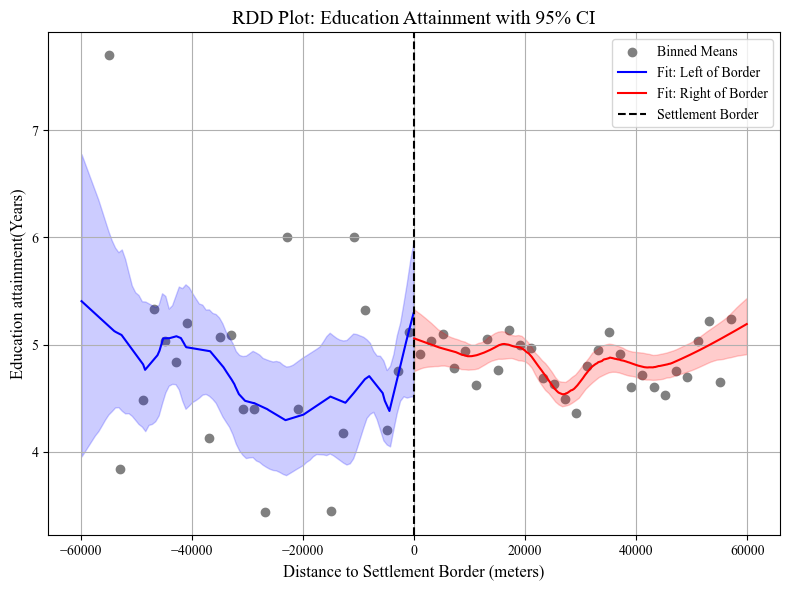

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# Prepare data
x = household_geo["dist_to_border_m"].to_numpy()
y = household_geo["mv107"].to_numpy()
df = pd.DataFrame({'x': x, 'y': y}).dropna()

# Bin means
bin_width = 2000
bins = np.arange(df['x'].min(), df['x'].max(), bin_width)
df['x_binned'] = pd.cut(df['x'], bins)
bin_means = df.groupby('x_binned').mean().dropna()
# Map bin midpoints only for bins that actually exist in bin_means
bin_labels = df['x_binned'].cat.categories
bin_centers = bins[:-1] + bin_width / 2
label_to_center = dict(zip(bin_labels, bin_centers))
bin_means['bin_mid'] = bin_means.index.map(label_to_center)


# Split left and right
df_left = df[df['x'] < 0]
df_right = df[df['x'] >= 0]

# LOWESS fit
lowess_left = lowess(df_left['y'], df_left['x'], frac=0.3, return_sorted=True)
lowess_right = lowess(df_right['y'], df_right['x'], frac=0.3, return_sorted=True)

# Bootstrap CI function
def bootstrap_ci(data, x_col, y_col, frac=0.3, n_bootstrap=100):
    x_vals = np.linspace(data[x_col].min(), data[x_col].max(), 100)
    y_boots = np.zeros((n_bootstrap, len(x_vals)))
    for i in range(n_bootstrap):
        sample = data.sample(frac=1, replace=True)
        fit = lowess(sample[y_col], sample[x_col], frac=frac, return_sorted=False)
        interp = np.interp(x_vals, np.sort(sample[x_col]), fit[np.argsort(sample[x_col])])
        y_boots[i, :] = interp
    lower = np.percentile(y_boots, 2.5, axis=0)
    upper = np.percentile(y_boots, 97.5, axis=0)
    return x_vals, lower, upper

# Compute bootstrapped CI
x_l, y_l, y_u = bootstrap_ci(df_left, 'x', 'y')
x_r, y_l_r, y_u_r = bootstrap_ci(df_right, 'x', 'y')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Binned means
ax.scatter(bin_means['bin_mid'], bin_means['y'], color='gray', label='Binned Means')

# LOWESS line + CI left
ax.plot(lowess_left[:, 0], lowess_left[:, 1], color='blue', label='Fit: Left of Border')
ax.fill_between(x_l, y_l, y_u, color='blue', alpha=0.2)

# LOWESS line + CI right
ax.plot(lowess_right[:, 0], lowess_right[:, 1], color='red', label='Fit: Right of Border')
ax.fill_between(x_r, y_l_r, y_u_r, color='red', alpha=0.2)

# Border line
ax.axvline(x=0, color='black', linestyle='--', label='Settlement Border')

# Labels
ax.set_xlabel("Distance to Settlement Border (meters)", fontsize=12)
ax.set_ylabel("Education attainment(Years)", fontsize=12)
ax.set_title("RDD Plot: Education Attainment with 95% CI", fontsize=14)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


### 1.5.2 men 2014 -wealth

In [61]:
# rdd regression result 8:23-9:00
# y: educ
# running var: within, distance to the border_m-dist_to_border_m
# covariates: age-v012, age^2, gender-v151-sex of household head...
# plot the result using the graphs.... 
import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# 1. ASSUME YOU ALREADY HAVE A GDF: household_geo
#    with columns:
#      - 'v190a' as outcome
#      - 'dist_to_border_m' as running variable
#      - 'v012' (age)
#      - 'v151' (gender/sex of household head)
#
#    Also, any rows with NaN in relevant columns should be dropped.
# ---------------------------------------------------------

# Example: drop rows with NaN in key columns
household_geo = household_geo.dropna(
    subset=["mv190", "dist_to_border_m", "mv012", "mv151","UN_Population_Count_2015","kalenjin","kikuyu","kamba","luhya","luo"]
)

# ---------------------------------------------------------
# 2. CREATE THE "TREATMENT" VARIABLE
#    treatment = 1 if dist_to_border_m >= 0, else 0
#    This indicates which side of the threshold each obs is on.
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. (OPTIONAL) CENTER THE RUNNING VARIABLE AROUND THE CUTOFF
#    We'll call this dist_cent = dist_to_border_m - 0
#    and also create a quadratic term for it.
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # (cutoff is 0)
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. CREATE AGE SQUARED (v012^2) AS AN EXAMPLE COVARIATE
# ---------------------------------------------------------
household_geo["v012_sq"] = household_geo["mv012"] ** 2

# ---------------------------------------------------------
# 5. SPECIFY THE RDD REGRESSION FORMULA
#
#    We'll do a simple polynomial specification:
#    v190a = α + τ*(treatment) + f(dist_cent) + g(X covariates) + ε
# ---------------------------------------------------------
formula = (
    "mv190 ~ treatment + dist_cent + dist_cent_sq + mv012 + v012_sq + mv151+ UN_Population_Count_2015+ kalenjin+ kikuyu+luhya+luo+kamba"
)

# ---------------------------------------------------------
# 6. FIT THE MODEL USING statsmodels OLS
# ---------------------------------------------------------
model = smf.ols(formula=formula, data=household_geo).fit()

# ---------------------------------------------------------
# 7. VIEW THE RESULTS
# ---------------------------------------------------------
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  mv190   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.072
Method:                 Least Squares   F-statistic:                     25.24
Date:                Fri, 02 May 2025   Prob (F-statistic):           2.67e-55
Time:                        20:23:05   Log-Likelihood:                -5971.4
No. Observations:                3746   AIC:                         1.197e+04
Df Residuals:                    3733   BIC:                         1.205e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

#### rdrobust

In [141]:
import pandas as pd
import numpy as np
import rdrobust  # make sure rdrobust is installed

# 1. Drop missing values
household_geo = household_geo.dropna(
    subset=["mv190", "dist_to_border_m", "mv012", "mv151", "mv005", 
            "kalenjin", "kikuyu", "luhya", "luo", "kamba", "UN_Population_Count_2020"]
)

# 2. Define key variables
y = household_geo["mv190"].to_numpy()
x = household_geo["dist_to_border_m"].to_numpy()
covs = household_geo[["mv012", "mv151", "UN_Population_Count_2020", 
                      "kalenjin", "kikuyu", "luhya", "luo", "kamba"]].to_numpy()
weights = household_geo["mv005"].to_numpy() / 1_000_000

# 3. Run rdrobust with controls and weights
result = rdrobust.rdrobust(y=y, x=x, covs=covs, weights=weights, p=2, bwselect='msetwo')

# 4. Print results
print(result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                  8281
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           574       7707
Number of Unique Obs.             66        946
Number of Effective Obs.         197       1759
Bandwidth Estimation       10978.942   13180.43
Bandwidth Bias             13425.387  19496.316
rho (h/b)                      0.818      0.676

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -1.352    0.166   -8.127   4.403e-16   [-1.678, -1.026]
Robust     

/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_60153/2770444126.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


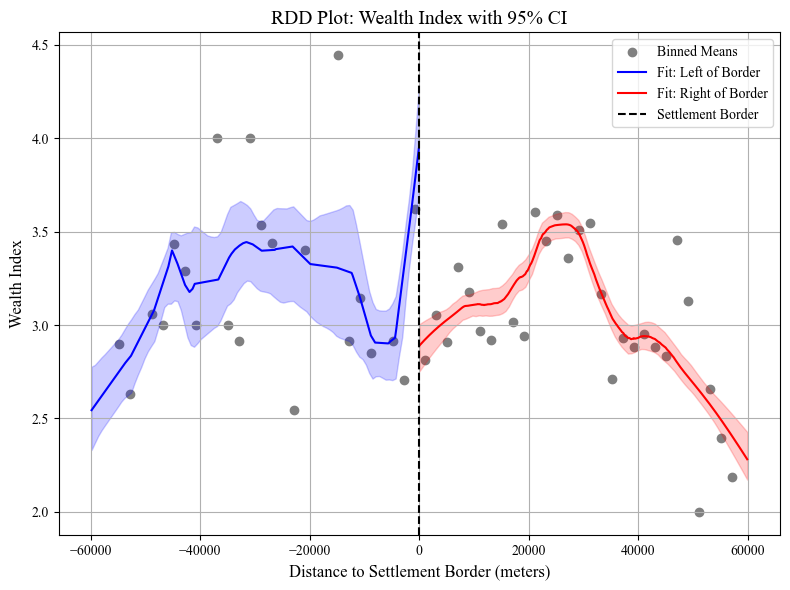

In [83]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from statsmodels.nonparametric.smoothers_lowess import lowess

# Prepare data
x = household_geo["dist_to_border_m"].to_numpy()
y = household_geo["mv190"].to_numpy()
df = pd.DataFrame({'x': x, 'y': y}).dropna()

# Bin means
bin_width = 2000
bins = np.arange(df['x'].min(), df['x'].max(), bin_width)
df['x_binned'] = pd.cut(df['x'], bins)
bin_means = df.groupby('x_binned').mean().dropna()
# Map bin midpoints only for bins that actually exist in bin_means
bin_labels = df['x_binned'].cat.categories
bin_centers = bins[:-1] + bin_width / 2
label_to_center = dict(zip(bin_labels, bin_centers))
bin_means['bin_mid'] = bin_means.index.map(label_to_center)


# Split left and right
df_left = df[df['x'] < 0]
df_right = df[df['x'] >= 0]

# LOWESS fit
lowess_left = lowess(df_left['y'], df_left['x'], frac=0.3, return_sorted=True)
lowess_right = lowess(df_right['y'], df_right['x'], frac=0.3, return_sorted=True)

# Bootstrap CI function
def bootstrap_ci(data, x_col, y_col, frac=0.3, n_bootstrap=100):
    x_vals = np.linspace(data[x_col].min(), data[x_col].max(), 100)
    y_boots = np.zeros((n_bootstrap, len(x_vals)))
    for i in range(n_bootstrap):
        sample = data.sample(frac=1, replace=True)
        fit = lowess(sample[y_col], sample[x_col], frac=frac, return_sorted=False)
        interp = np.interp(x_vals, np.sort(sample[x_col]), fit[np.argsort(sample[x_col])])
        y_boots[i, :] = interp
    lower = np.percentile(y_boots, 2.5, axis=0)
    upper = np.percentile(y_boots, 97.5, axis=0)
    return x_vals, lower, upper

# Compute bootstrapped CI
x_l, y_l, y_u = bootstrap_ci(df_left, 'x', 'y')
x_r, y_l_r, y_u_r = bootstrap_ci(df_right, 'x', 'y')

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Binned means
ax.scatter(bin_means['bin_mid'], bin_means['y'], color='gray', label='Binned Means')

# LOWESS line + CI left
ax.plot(lowess_left[:, 0], lowess_left[:, 1], color='blue', label='Fit: Left of Border')
ax.fill_between(x_l, y_l, y_u, color='blue', alpha=0.2)

# LOWESS line + CI right
ax.plot(lowess_right[:, 0], lowess_right[:, 1], color='red', label='Fit: Right of Border')
ax.fill_between(x_r, y_l_r, y_u_r, color='red', alpha=0.2)

# Border line
ax.axvline(x=0, color='black', linestyle='--', label='Settlement Border')

# Labels
ax.set_xlabel("Distance to Settlement Border (meters)", fontsize=12)
ax.set_ylabel("Wealth Index", fontsize=12)
ax.set_title("RDD Plot: Wealth Index with 95% CI", fontsize=14)
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


### 1.5.3 men 2022 - market

In [62]:
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["mv107", "dist_to_border_m", "mv012", "mv151", "mv005","UN_Population_Count_2020","kalenjin","kikuyu","kamba","luhya","luo" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["mv012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["mv005"] / 1_000_000

household_geo1["popu"] = household_geo1["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "mv107 ~ treatment + dist_cent + dist_cent_sq + mv151 + age_sq + mv012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  mv107   R-squared:                       0.011
Model:                            WLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     2.941
Date:                Fri, 02 May 2025   Prob (F-statistic):            0.00458
Time:                        20:23:11   Log-Likelihood:                -4699.8
No. Observations:                1927   AIC:                             9416.
Df Residuals:                    1919   BIC:                             9460.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.5117      0.319     14.152   

In [142]:
import pandas as pd
import numpy as np
import rdrobust  # make sure rdrobust is installed
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]

# 1. Drop missing values
household_geo1 = household_geo1.dropna(
    subset=["mv107", "dist_to_border_m", "mv012", "mv151", "mv005", 
            "kalenjin", "kikuyu", "luhya", "luo", "kamba", "UN_Population_Count_2020"]
)

# 2. Define key variables
y = household_geo1["mv107"].to_numpy()
x = household_geo1["dist_to_border_m"].to_numpy()
covs = household_geo1[["mv012", "mv151", "UN_Population_Count_2020", 
                      "kalenjin", "kikuyu", "luhya", "luo", "kamba"]].to_numpy()
weights = household_geo1["mv005"].to_numpy() / 1_000_000

# 3. Run rdrobust with controls and weights
result = rdrobust.rdrobust(y=y, x=x, covs=covs, weights=weights, p=2, bwselect='msetwo')

# 4. Print results
print(result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                  4157
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           385       3772
Number of Unique Obs.             44        461
Number of Effective Obs.         162       1810
Bandwidth Estimation       29981.287   23818.03
Bandwidth Bias             34974.065  32796.899
rho (h/b)                      0.857      0.726

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.464    0.482    0.962   3.361e-01     [-0.482, 1.41]
Robust     

In [63]:
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
# near
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 1]
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["mv107", "dist_to_border_m", "mv012", "mv151", "mv005","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["mv012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["mv005"] / 1_000_000

household_geo1["popu"] = household_geo1["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "mv107 ~ treatment + dist_cent + dist_cent_sq + mv151 + age_sq + mv012 +popu+ kalenjin+ kikuyu+luhya+luo+kamba"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  mv107   R-squared:                       0.038
Model:                            WLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     5.881
Date:                Fri, 02 May 2025   Prob (F-statistic):           4.11e-10
Time:                        20:23:15   Log-Likelihood:                -4380.7
No. Observations:                1819   AIC:                             8787.
Df Residuals:                    1806   BIC:                             8859.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.1916      0.372      8.587   

In [143]:
import pandas as pd
import numpy as np
import rdrobust  # make sure rdrobust is installed
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 1]

# 1. Drop missing values
household_geo1 = household_geo1.dropna(
    subset=["mv107", "dist_to_border_m", "mv012", "mv151", "mv005", 
            "kalenjin", "kikuyu", "luhya", "luo", "kamba", "UN_Population_Count_2020"]
)

# 2. Define key variables
y = household_geo1["mv107"].to_numpy()
x = household_geo1["dist_to_border_m"].to_numpy()
covs = household_geo1[["mv012", "mv151", "UN_Population_Count_2020", 
                      "kalenjin", "kikuyu", "luhya", "luo", "kamba"]].to_numpy()
weights = household_geo1["mv005"].to_numpy() / 1_000_000

# 3. Run rdrobust with controls and weights
result = rdrobust.rdrobust(y=y, x=x, covs=covs, weights=weights, p=2, bwselect='msetwo')

# 4. Print results
print(result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                  4124
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           189       3935
Number of Unique Obs.             22        485
Number of Effective Obs.          82        929
Bandwidth Estimation       18930.034  13727.035
Bandwidth Bias             23921.773  20750.627
rho (h/b)                      0.791      0.662

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.609    0.872   -0.698   4.852e-01    [-2.318, 1.101]
Robust     

### 1.6.1 pr 2014 -edu

In [28]:
#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2014_DHS_10032024_1837_218744/KEPR72DT/KEPR72FL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'hv001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')


In [29]:
# if is within the settlement area, the distance is positive, otherwise negative
household_geo.loc[
    household_geo["within_settlement"] == 1, 
    "dist_to_border_m"
] *= -1

In [ ]:
# 导出 方便r操作
household_geo.to_csv("/Users/huiyu/Downloads/household_geo_pr_2014.csv")

#### balance table 


In [66]:
merged_df =cluster_points_withgeo

from scipy import stats
import pandas as pd

# Define the columns for which we want to calculate the p-values
variables = ['All_Population_Count_2015', 'Aridity_2015', 'Day_Land_Surface_Temp_2015', 'Malaria_Incidence_2015',
             'Elevation', 'Irrigation', "Travel_Times", "Rainfall_2020","Rainfall_2015","Rainfall_2010" ,"Growing_Season_Length", 
             "UN_Population_Density_2020","Global_Human_Footprint"]

# Create an empty DataFrame to store mean values, p-values, and counts
mean_values = pd.DataFrame(columns=['Inside', 'Outside', 'p-value', 'Count_Inside', 'Count_Outside'], index=variables)

# Calculate mean values, p-values, and counts for each variable
for var in variables:
    inside_values = merged_df[merged_df['within_settlement'] == 1][var]
    outside_values = merged_df[merged_df['within_settlement'] == 0][var]
    
    # Calculate mean for 'Inside' and 'Outside'
    mean_values.at[var, 'Inside'] = inside_values.mean()
    mean_values.at[var, 'Outside'] = outside_values.mean()
    
    # Perform t-test and store the p-value
    t_stat, p_value = stats.ttest_ind(inside_values, outside_values, nan_policy='omit')
    mean_values.at[var, 'p-value'] = p_value
    
    # Store the number of observations for each group
    mean_values.at[var, 'Count_Inside'] = inside_values.count()
    mean_values.at[var, 'Count_Outside'] = outside_values.count()

# Display the table
print(mean_values)
mean_values.to_csv("/Users/huiyu/Documents/uchicago/kenya project/data/full_data_geo_cov_v1_40km.csv")

# Optionally, you can save the table as a CSV file if needed
# mean_values.to_csv('/path/to/save/mean_values_with_p_values_table.csv')

                                 Inside      Outside   p-value Count_Inside  \
All_Population_Count_2015     440.61429    830.62822  0.087764           35   
Aridity_2015                  28.535191    29.957456  0.463111           35   
Day_Land_Surface_Temp_2015    30.983029    30.473303  0.418261           35   
Malaria_Incidence_2015         0.097639     0.078684  0.159855           35   
Elevation                   1481.342716  1378.770554  0.401811           35   
Irrigation                     0.655333     1.079529  0.364753           35   
Travel_Times                  58.463138    50.339529  0.436294           35   
Rainfall_2020                1649.45897   1757.35069  0.403386           35   
Rainfall_2015               1215.527902  1291.611016  0.380747           35   
Rainfall_2010               1179.531676  1294.966605  0.208621           35   
Growing_Season_Length          9.171429      9.82134  0.289638           35   
UN_Population_Density_2020   626.564762   1034.61459

In [67]:
#educ balance table 2022
from scipy import stats
import pandas as pd

# Define the columns for which we want to calculate the p-values
#v012- age,v131-ethnics, v149 eudcation att， v106: higher education level, v107 hihest year of education, v438 height,v190a:wealth index for urbn/rural
# v131:ethnicity, v438:responendent height , hw3_1:child height , v745b:own land or jointly
#sreduc:respondent education, 

# for the household dataset, the education- sex- hc27;age-hv105 ; wealthindex -hv270 ; chid height-hc3 ; own land -hv244(use land for agroculture)/sh118_b  ;
# ethnicitcity ; responsdent height -ha3; hv009- number of family numbers; hv011- number of eligible men' hv010: number of eligible women
# 还差ethinicity

variables = ["hc3","hc27","hv244","hv105","sh118_b","ha3",'hv009',"hv011" ,'hv010']

# Create an empty DataFrame to store mean values and p-values
mean_values = pd.DataFrame(columns=['Inside', 'Outside', 'p-value'], index=variables)

# Calculate mean values and p-values for each variable
for var in variables:
    inside_values = household_geo[household_geo['within_settlement'] == 1][var]
    outside_values = household_geo[household_geo['within_settlement'] == 0][var]
    
    # Calculate mean for 'Inside' and 'Outside'
    mean_values.at[var, 'Inside'] = inside_values.mean()
    mean_values.at[var, 'Outside'] = outside_values.mean()
    
    # Perform t-test and store the p-value
    t_stat, p_value = stats.ttest_ind(inside_values, outside_values, nan_policy='omit')
    mean_values.at[var, 'p-value'] = p_value

# Display the table
print(mean_values)
mean_values.to_csv("/Users/huiyu/Documents/uchicago/kenya project/data/var_v1_20km.csv")

# 统计hh数量，然后做女性的balance table

             Inside      Outside   p-value
hc3      994.346604  1059.612807  0.345967
hc27       1.512761     1.494305  0.461918
hv244      0.839878     0.822786  0.013502
hv105     23.265145    23.388577  0.722672
sh118_b    1.318887     1.328629  0.578932
ha3       2142.3207  2176.292991  0.774826
hv009      5.679452     5.561783  0.011283
hv011      0.551903     0.491599  0.000041
hv010      1.179604      1.17423  0.724183


In [48]:
print("within household member number: ",len(household_geo[household_geo['within_settlement'] == 1]))
print("outside household member number: ",len(household_geo[household_geo['within_settlement'] == 0]))


within household member number:  2545
outside household member number:  33954


In [7]:
#education--正但是不显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["hv107", "dist_to_border_m", "hv105", "hv104", "hv005","UN_Population_Count_2020" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "hv107 ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  hv107   R-squared:                       0.150
Model:                            WLS   Adj. R-squared:                  0.149
Method:                 Least Squares   F-statistic:                     700.0
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        21:56:15   Log-Likelihood:                -65847.
No. Observations:               27878   AIC:                         1.317e+05
Df Residuals:                   27870   BIC:                         1.318e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.3492      0.069     19.469   

#### rdrobust

In [8]:
import numpy as np
from rdrobust import rdrobust

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["hv107", "dist_to_border_m", "hv105", "hv104", "hv005", "UN_Population_Count_2020"]
)

# ---------------------------------------------------------
# 2. Define outcome, running variable, covariates, weights
# ---------------------------------------------------------
outcome = household_geo["hv107"].values
running = household_geo["dist_to_border_m"].values

covariates = household_geo[["hv105", "hv104", "UN_Population_Count_2020"]].values
weights = household_geo["hv005"].values / 1_000_000

# ---------------------------------------------------------
# 3. Run rdrobust (local polynomial with covariates and weights)
# ---------------------------------------------------------
rd_result = rdrobust(
    y=outcome,
    x=running,
    covs=covariates,
    weights=weights,
    p=2,              # Local quadratic polynomial
    bwselect='msetwo' # Optimal bandwidth selector
)

# ---------------------------------------------------------
# 4. Print rdrobust results
# ---------------------------------------------------------
print(rd_result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                 27878
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations          1990      25888
Number of Unique Obs.             28        357
Number of Effective Obs.        1370       3226
Bandwidth Estimation        6354.915   4390.681
Bandwidth Bias              8728.397    6727.45
rho (h/b)                      0.728      0.653

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.432    0.213   -2.027   4.263e-02   [-0.849, -0.014]
Robust     

### 1.6.2 pr 2014 -wealth

In [70]:
# wealth index--还是正的，符合

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["hv270", "dist_to_border_m", "hv105", "hv104", "hv005", "UN_Population_Count_2020"]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "hv270 ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 + popu "

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  hv270   R-squared:                       0.027
Model:                            WLS   Adj. R-squared:                  0.026
Method:                 Least Squares   F-statistic:                     125.3
Date:                Fri, 02 May 2025   Prob (F-statistic):          1.40e-182
Time:                        20:25:28   Log-Likelihood:                -55444.
No. Observations:               31969   AIC:                         1.109e+05
Df Residuals:                   31961   BIC:                         1.110e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.4751      0.035     71.419   

In [10]:
import numpy as np
from rdrobust import rdrobust

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["hv270", "dist_to_border_m", "hv105", "hv104", "hv005", "UN_Population_Count_2020"]
)

# ---------------------------------------------------------
# 2. Define outcome, running variable, covariates, weights
# ---------------------------------------------------------
outcome = household_geo["hv270"].values
running = household_geo["dist_to_border_m"].values

covariates = household_geo[["hv105", "hv104", "UN_Population_Count_2020"]].values
weights = household_geo["hv005"].values / 1_000_000

# ---------------------------------------------------------
# 3. Run rdrobust (local polynomial with covariates and weights)
# ---------------------------------------------------------
rd_result = rdrobust(
    y=outcome,
    x=running,
    covs=covariates,
    weights=weights,
    p=2,              # Local quadratic polynomial
    bwselect='msetwo' # Optimal bandwidth selector
)

# ---------------------------------------------------------
# 4. Print rdrobust results
# ---------------------------------------------------------
print(rd_result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                 27878
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations          1990      25888
Number of Unique Obs.             28        357
Number of Effective Obs.         745       3143
Bandwidth Estimation        2180.949   4049.441
Bandwidth Bias              3729.309   5502.267
rho (h/b)                      0.585      0.736

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.415    0.115   -3.605   3.126e-04    [-0.64, -0.189]
Robust     

### 1.6.3 pr 2014- market

In [71]:
#对于偏远地区（远离市场地区，情况是否会更严重？）正但是不显著
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]

#education--正但是不显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["hv107", "dist_to_border_m", "hv105", "hv104", "hv005","UN_Population_Count_2020"]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["hv005"] / 1_000_000

household_geo1["popu"] = household_geo1["UN_Population_Count_2020"]
# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "hv107 ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 + popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  hv107   R-squared:                       0.181
Model:                            WLS   Adj. R-squared:                  0.181
Method:                 Least Squares   F-statistic:                     534.4
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        20:25:33   Log-Likelihood:                -39547.
No. Observations:               16914   AIC:                         7.911e+04
Df Residuals:                   16906   BIC:                         7.917e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.1060      0.086     12.865   

In [22]:
#对于偏远地区（远离市场地区，情况是否会更严重？）正但是不显著
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
# near
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 1]

#education--正但是不显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["hv107", "dist_to_border_m", "hv105", "hv104", "hv005","UN_Population_Count_2020"]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["hv005"] / 1_000_000

household_geo1["popu"] = household_geo1["UN_Population_Count_2020"]
# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "hv107 ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 + popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  hv107   R-squared:                       0.128
Model:                            WLS   Adj. R-squared:                  0.128
Method:                 Least Squares   F-statistic:                     279.1
Date:                Wed, 30 Apr 2025   Prob (F-statistic):               0.00
Time:                        21:16:05   Log-Likelihood:                -31517.
No. Observations:               13320   AIC:                         6.305e+04
Df Residuals:                   13312   BIC:                         6.311e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        1.5870      0.104     15.293   

#### rdr

In [11]:
import numpy as np
from rdrobust import rdrobust

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]

household_geo1 = household_geo1.dropna(
    subset=["hv107", "dist_to_border_m", "hv105", "hv104", "hv005", "UN_Population_Count_2020"]
)

# ---------------------------------------------------------
# 2. Define outcome, running variable, covariates, weights
# ---------------------------------------------------------
outcome = household_geo1["hv107"].values
running = household_geo1["dist_to_border_m"].values

covariates = household_geo1[["hv105", "hv104", "UN_Population_Count_2020"]].values
weights = household_geo1["hv005"].values / 1_000_000

# ---------------------------------------------------------
# 3. Run rdrobust (local polynomial with covariates and weights)
# ---------------------------------------------------------
rd_result = rdrobust(
    y=outcome,
    x=running,
    covs=covariates,
    weights=weights,
    p=2,              # Local quadratic polynomial
    bwselect='msetwo' # Optimal bandwidth selector
)

# ---------------------------------------------------------
# 4. Print rdrobust results
# ---------------------------------------------------------
print(rd_result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                 14558
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations          1382      13176
Number of Unique Obs.             18        174
Number of Effective Obs.         638       3556
Bandwidth Estimation        2190.219   8555.326
Bandwidth Bias              3475.606  12134.249
rho (h/b)                       0.63      0.705

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.712    0.382   -1.862   6.267e-02    [-1.462, 0.038]
Robust     

In [12]:
import numpy as np
from rdrobust import rdrobust

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 1]

household_geo1 = household_geo1.dropna(
    subset=["hv107", "dist_to_border_m", "hv105", "hv104", "hv005", "UN_Population_Count_2020"]
)

# ---------------------------------------------------------
# 2. Define outcome, running variable, covariates, weights
# ---------------------------------------------------------
outcome = household_geo1["hv107"].values
running = household_geo1["dist_to_border_m"].values

covariates = household_geo1[["hv105", "hv104", "UN_Population_Count_2020"]].values
weights = household_geo1["hv005"].values / 1_000_000

# ---------------------------------------------------------
# 3. Run rdrobust (local polynomial with covariates and weights)
# ---------------------------------------------------------
rd_result = rdrobust(
    y=outcome,
    x=running,
    covs=covariates,
    weights=weights,
    p=2,              # Local quadratic polynomial
    bwselect='msetwo' # Optimal bandwidth selector
)

# ---------------------------------------------------------
# 4. Print rdrobust results
# ---------------------------------------------------------
print(rd_result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                 13320
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations           608      12712
Number of Unique Obs.             10        183
Number of Effective Obs.         298       2094
Bandwidth Estimation        5643.095   4869.949
Bandwidth Bias              8889.344   7095.448
rho (h/b)                      0.635      0.686

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional       0.444    0.475    0.935   3.499e-01    [-0.487, 1.375]
Robust     

### 1.6.4 pr 2014 - dropout

In [13]:
# load dataset kehr
#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2022_DHS_09262024_2340_218744/KEPR8CDT/KEPR8CFL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'hv001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')
# merge based on clustid
# check if variables are all in dataset

In [30]:
household_geo["not_attend"] = np.where(household_geo["hv129"].isin([0,4]), 1, 0)

In [31]:
household_geo["attend"] = np.where(household_geo["hv129"].isin([1,2,3]), 1, 0)

In [16]:
### 1.1.3 women 2022 - market
#dropout--负并且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["not_attend", "dist_to_border_m", "hv105", "hv104", "hv005","UN_Population_Count_2020"]
)
# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "not_attend ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())



                            WLS Regression Results                            
Dep. Variable:             not_attend   R-squared:                       0.061
Model:                            WLS   Adj. R-squared:                  0.061
Method:                 Least Squares   F-statistic:                     384.6
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        22:05:01   Log-Likelihood:                -8223.8
No. Observations:               35294   AIC:                         1.646e+04
Df Residuals:                   35287   BIC:                         1.652e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.1577      0.007     24.019   

In [32]:
### 1.1.3 women 2022 - market
#dropout--负并且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["attend", "dist_to_border_m", "hv105", "hv104", "hv005","UN_Population_Count_2020"]
)
# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2020"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "attend ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())



                            WLS Regression Results                            
Dep. Variable:                 attend   R-squared:                       0.164
Model:                            WLS   Adj. R-squared:                  0.164
Method:                 Least Squares   F-statistic:                     1025.
Date:                Fri, 02 May 2025   Prob (F-statistic):               0.00
Time:                        12:11:29   Log-Likelihood:                -24933.
No. Observations:               36495   AIC:                         4.988e+04
Df Residuals:                   36487   BIC:                         4.995e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.5670      0.010     57.068   

In [32]:
import numpy as np
from rdrobust import rdrobust

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["attend", "dist_to_border_m", "hv105", "hv104", "hv005", "UN_Population_Count_2010"]
)

# ---------------------------------------------------------
# 2. Define outcome, running variable, covariates, weights
# ---------------------------------------------------------
outcome = household_geo["attend"].values
running = household_geo["dist_to_border_m"].values

covariates = household_geo[["hv105", "hv104", "UN_Population_Count_2010"]].values
weights = household_geo["hv005"].values / 1_000_000

# ---------------------------------------------------------
# 3. Run rdrobust (local polynomial with covariates and weights)
# ---------------------------------------------------------
rd_result = rdrobust(
    y=outcome,
    x=running,
    covs=covariates,
    weights=weights,
    p=2,    
    c=0,           # Local quadratic polynomial
    bwselect='msetwo' # Optimal bandwidth selector
)

# ---------------------------------------------------------
# 4. Print rdrobust results
# ---------------------------------------------------------
print(rd_result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                 36495
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations          2545      33950
Number of Unique Obs.             28        357
Number of Effective Obs.        1387       9436
Bandwidth Estimation        5076.465   7871.559
Bandwidth Bias              7226.079  10566.112
rho (h/b)                      0.703      0.745

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.035     0.03   -1.171   2.414e-01    [-0.094, 0.024]
Robust     

In [33]:
import numpy as np
from rdrobust import rdrobust

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["not_attend", "dist_to_border_m", "hv105", "hv104", "hv005", "UN_Population_Count_2010"]
)

# ---------------------------------------------------------
# 2. Define outcome, running variable, covariates, weights
# ---------------------------------------------------------
outcome = household_geo["attend"].values
running = household_geo["dist_to_border_m"].values

covariates = household_geo[["hv105", "hv104", "UN_Population_Count_2010"]].values
weights = household_geo["hv005"].values / 1_000_000

# ---------------------------------------------------------
# 3. Run rdrobust (local polynomial with covariates and weights)
# ---------------------------------------------------------
rd_result = rdrobust(
    y=outcome,
    x=running,
    covs=covariates,
    weights=weights,
    p=2,    
    c=0,           # Local quadratic polynomial
    bwselect='msetwo' # Optimal bandwidth selector
)

# ---------------------------------------------------------
# 4. Print rdrobust results
# ---------------------------------------------------------
print(rd_result)


Mass points detected in the running variable.
Mass points detected in the running variable.
Call: rdrobust
Number of Observations:                 36495
Polynomial Order Est. (p):                  2
Polynomial Order Bias (q):                  3
Kernel:                            Triangular
Bandwidth Selection:                   msetwo
Var-Cov Estimator:                         NN

                                Left      Right
------------------------------------------------
Number of Observations          2545      33950
Number of Unique Obs.             28        357
Number of Effective Obs.        1387       9436
Bandwidth Estimation        5076.465   7871.559
Bandwidth Bias              7226.079  10566.112
rho (h/b)                      0.703      0.745

Method             Coef.     S.E.   t-stat    P>|t|       95% CI      
-------------------------------------------------------------------------
Conventional      -0.035     0.03   -1.171   2.414e-01    [-0.094, 0.024]
Robust     

总结：edu 对于women显著为负，对于men不显著，对于整体也不显著；wealth对于整体显著为证，对于men显著为证，对于woemn也显著为证，
market来说：对于women显著为负（越远edu越低），对men不显著，对整体显著为负，
dropout来说：对于整体显著为负, 说明无法解释,但是发现按attend来算，也是内部比外部高


In [23]:
print(np.min(running), np.max(running))

11.286069021096768 19957.698850603745


## 2007

Total clusters in the 20 km buffer: 158
    ├─ Clusters inside settlement polygons (in 20 km): 10
    └─ Clusters outside settlement polygons (in 20 km): 148


/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/3530157616.py:132: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


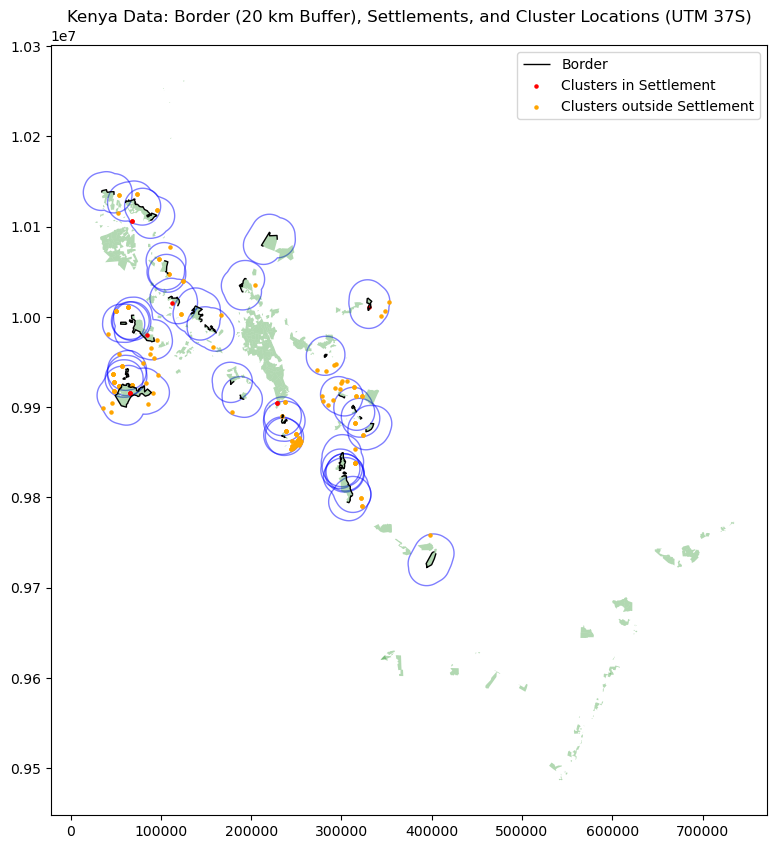

In [162]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# 1. LOAD THE DATA
# ---------------------------------------------------------------------

# 1.1 Load the border shapefile
border_shapefile = gpd.read_file(
    "/Users/huiyu/Downloads/full_border_draft_manual/full_border_test1.shp"
)

# 1.2 Load the settlement (polygon) shapefile
settlement_shapefile_path = "/Users/huiyu/Downloads/2222/MergedFeatures.shp"
settlement_data = gpd.read_file(settlement_shapefile_path)

# 1.3 Load the household cluster shapefile
cluster_shapefile_path = "/Users/huiyu/Documents/uchicago/kenya project/data/KE_2008-09_DHS_04302025_330_218744/KEGE52FL/KEGE52FL.shp"
data_cluster = gpd.read_file(cluster_shapefile_path)

# ---------------------------------------------------------------------
# 2. PROJECT DATA INTO A SUITABLE METER-BASED CRS FOR KENYA
#    We'll use EPSG:32737 (WGS 84 / UTM zone 37S).
# ---------------------------------------------------------------------

desired_crs = "EPSG:32737"

border_projected = border_shapefile.to_crs(desired_crs)
settlement_projected = settlement_data.to_crs(desired_crs)
cluster_projected = data_cluster.to_crs(desired_crs)


# ---------------------------------------------------------------------
# 2.1 LOAD MARKET DATA AND COMPUTE DISTANCE TO NEAREST MARKET
# ---------------------------------------------------------------------

# Load the market data
market_data = pd.read_excel("/Users/huiyu/Downloads/Markets.xlsx")  # Adjust path if needed

# Create GeoDataFrame for markets
market_gdf = gpd.GeoDataFrame(
    market_data,
    geometry=gpd.points_from_xy(market_data['GPS Longitude'], market_data['GPS Latitude']),
    crs="EPSG:4326"  # Original CRS (longitude/latitude)
)

# Project markets to the same CRS as the cluster data
market_projected = market_gdf.to_crs(desired_crs)

# Project cluster data (if not already projected)
cluster_projected = data_cluster.to_crs(desired_crs)

# Import nearest points function
from shapely.ops import nearest_points

# Define a function to calculate distance from a point to the nearest market
def nearest_market_distance(point, markets):
    nearest_geom = nearest_points(point, markets.unary_union)[1]
    return point.distance(nearest_geom)

# Apply the function: for each cluster point, find its nearest market
cluster_projected["distance_to_nearest_market"] = cluster_projected.geometry.apply(
    lambda pt: nearest_market_distance(pt, market_projected)
)

# ---------------------------------------------------------------------
# 3. CREATE 20 KM BUFFER AROUND THE BORDER
# ---------------------------------------------------------------------

# 3.1 Buffer in meters: 20 km = 20,000 m
border_buffer = border_projected.buffer(20000)

# 3.2 Convert the Series to a GeoDataFrame for spatial operations
border_buffer_gdf = gpd.GeoDataFrame(geometry=border_buffer, crs=desired_crs)

# ---------------------------------------------------------------------
# 4. FIND ALL CLUSTERS WITHIN THE 20 KM BUFFER
# ---------------------------------------------------------------------

clusters_in_20km = gpd.sjoin(
    cluster_projected, border_buffer_gdf, how="inner", predicate="intersects"
)

# ---------------------------------------------------------------------
# 5. WITHIN THOSE CLUSTERS, FIND WHICH ARE INSIDE/OUTSIDE THE SETTLEMENT POLYGONS
# ---------------------------------------------------------------------

# ----- Fix: drop the join-index columns -----
clusters_in_20km = clusters_in_20km.drop(columns=["index_left", "index_right"], errors="ignore")

# 5.1 Clusters within the polygons
clusters_in_20km_in_settlement = gpd.sjoin(
    clusters_in_20km, settlement_projected, how="inner", predicate="within"
)

# 5.2 Clusters outside the polygons (but still within the 20 km buffer)
clusters_in_20km_out_settlement = clusters_in_20km[
    ~clusters_in_20km.index.isin(clusters_in_20km_in_settlement.index)
]

# ---------------------------------------------------------------------
# 6. PRINT SIMPLE COUNTS
# ---------------------------------------------------------------------
print("Total clusters in the 20 km buffer:", len(clusters_in_20km))
print("    ├─ Clusters inside settlement polygons (in 20 km):", len(clusters_in_20km_in_settlement))
print("    └─ Clusters outside settlement polygons (in 20 km):", len(clusters_in_20km_out_settlement))

# ---------------------------------------------------------------------
# 7. PLOT ALL LAYERS ON A SINGLE FIGURE
# ---------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 10))

# 7.1 Plot the original border
border_projected.plot(ax=ax, edgecolor='black', facecolor='none', linewidth=1, label='Border')

# 7.2 Plot the 20 km buffer
border_buffer_gdf.plot(ax=ax, edgecolor='blue', facecolor='none', alpha=0.5, label='20 km Buffer')

# 7.3 Plot the settlement polygons
settlement_projected.plot(ax=ax, color='green', alpha=0.3, label='Settlement Polygons')

# 7.4 Plot the clusters within 20 km & in settlement polygons
clusters_in_20km_in_settlement.plot(ax=ax, color='red', markersize=5, label='Clusters in Settlement')

# 7.5 Plot the clusters within 20 km & outside settlement polygons
clusters_in_20km_out_settlement.plot(ax=ax, color='orange', markersize=5, label='Clusters outside Settlement')

# 7.6 Customize and show the plot
ax.set_title("Kenya Data: Border (20 km Buffer), Settlements, and Cluster Locations (UTM 37S)")
plt.legend()
plt.show()


In [163]:

# 1. Compute the unified border geometry (single shape)
# ---------------------------------------------------------------------
border_union = border_projected.unary_union

# ---------------------------------------------------------------------
# 2. Add distance-to-border (in meters) for "in settlement" clusters
# ---------------------------------------------------------------------
clusters_in_20km_in_settlement["dist_to_border_m"] = (
    clusters_in_20km_in_settlement.geometry.distance(border_union)
)

# ---------------------------------------------------------------------
# 3. Add distance-to-border (in meters) for "out settlement" clusters
# ---------------------------------------------------------------------
clusters_in_20km_out_settlement["dist_to_border_m"] = (
    clusters_in_20km_out_settlement.geometry.distance(border_union)
)

# ---------------------------------------------------------------------
# 4. Preview the results
# ---------------------------------------------------------------------
print("\nClusters in settlement (distance to border, first 5 rows):")
print(clusters_in_20km_in_settlement[["geometry", "dist_to_border_m"]].head())

print("\nClusters out settlement (distance to border, first 5 rows):")
print(clusters_in_20km_out_settlement[["geometry", "dist_to_border_m"]].head())


Clusters in settlement (distance to border, first 5 rows):
                           geometry  dist_to_border_m
152   POINT (84934.468 9979974.921)       3859.289407
85   POINT (68045.324 10105837.815)      17624.328626
85   POINT (68045.324 10105837.815)      17624.328626
224   POINT (65518.550 9915300.980)       3734.567488
224   POINT (65518.550 9915300.980)       3734.567488

Clusters out settlement (distance to border, first 5 rows):
                           geometry  dist_to_border_m
5    POINT (315363.646 9882100.556)       6756.573977
335  POINT (323588.681 9868939.903)       5140.167067
5    POINT (315363.646 9882100.556)       6756.573977
335  POINT (323588.681 9868939.903)       5140.167067
5    POINT (315363.646 9882100.556)       6756.573977


/Users/huiyu/opt/anaconda3/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [164]:
clusters_in_20km_in_settlement=clusters_in_20km_in_settlement.drop_duplicates()
clusters_in_20km_out_settlement=clusters_in_20km_out_settlement.drop_duplicates()
clusters_in_20km_in_settlement["within_settlement"] =1
clusters_in_20km_out_settlement["within_settlement"] = 0

cluster_points = gpd.pd.concat(
    [clusters_in_20km_in_settlement, clusters_in_20km_out_settlement],
    ignore_index=True
)
median_distance = cluster_points["distance_to_nearest_market"].median()
print(f"The median distance to nearest market is {median_distance:.2f} meters.")
# Step 2: Create the new column based on the median
cluster_points["market_distance_above_median"] = cluster_points["distance_to_nearest_market"].apply(
    lambda x: 0 if x > median_distance else 1
)

The median distance to nearest market is 3797.96 meters.


/Users/huiyu/opt/anaconda3/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/huiyu/opt/anaconda3/lib/python3.9/site-packages/geopandas/geodataframe.py:1528: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [165]:
# match geo cov : test weather and sol
import pandas as pd
### geo cov data: 
# Assuming `geo_cov` and `cluster_data_combined` DataFrames are loaded
geo_cov=pd.read_csv("/Users/huiyu/Documents/uchicago/kenya project/data/KE_2008-09_DHS_04302025_330_218744/KEGC52FL/KEGC52FL.csv")
# Merge the two DataFrames based on the 'DHSCLUST' column
cluster_points_withgeo = pd.merge(cluster_points, geo_cov, on='DHSCLUST', how='left')

In [170]:
cluster_points_withgeo["UN_Population_Count_2010"]

0      38.704406
1      67.328531
2      50.699399
3      21.273398
4     104.649333
         ...    
85     13.828531
86     40.564843
87     18.539641
88     46.916992
89     57.920410
Name: U5_Population_2010, Length: 90, dtype: float64

### 2.1 women 2007 -edu

In [167]:
#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2008-09_DHS_04302025_330_218744/KEIR52DT/KEIR52FL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'v001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')

In [168]:
# if is within the settlement area, the distance is positive, otherwise negative
household_geo.loc[
    household_geo["within_settlement"] == 1, 
    "dist_to_border_m"
] *= -1

In [171]:
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["v107", "dist_to_border_m", "v012", "v151", "v005","UN_Population_Count_2010" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["v005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2010"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v107 ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                   v107   R-squared:                       0.007
Model:                            WLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.792
Date:                Tue, 29 Apr 2025   Prob (F-statistic):             0.0848
Time:                        22:52:31   Log-Likelihood:                -4116.4
No. Observations:                1697   AIC:                             8249.
Df Residuals:                    1689   BIC:                             8292.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        5.6455      0.289     19.503   

/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/1390885465.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)
/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/1390885465.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/1390885465.py:24: SettingWi

### 2.2 women 2007 -wealth

In [173]:
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["v190", "dist_to_border_m", "v012", "v151", "v005","UN_Population_Count_2010" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["v005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2010"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v190 ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                   v190   R-squared:                       0.039
Model:                            WLS   Adj. R-squared:                  0.035
Method:                 Least Squares   F-statistic:                     9.721
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           6.49e-12
Time:                        22:53:12   Log-Likelihood:                -3074.4
No. Observations:                1697   AIC:                             6165.
Df Residuals:                    1689   BIC:                             6208.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.5856      0.157     16.505   

### 2.3 women 2007 -market

In [174]:
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["v107", "dist_to_border_m", "v012", "v151", "v005","UN_Population_Count_2010" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["v012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["v005"] / 1_000_000

household_geo1["popu"] = household_geo1["UN_Population_Count_2010"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "v107 ~ treatment + dist_cent + dist_cent_sq + v151 + age_sq + v012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                   v107   R-squared:                       0.013
Model:                            WLS   Adj. R-squared:                  0.005
Method:                 Least Squares   F-statistic:                     1.677
Date:                Tue, 29 Apr 2025   Prob (F-statistic):              0.111
Time:                        22:53:44   Log-Likelihood:                -2208.5
No. Observations:                 932   AIC:                             4433.
Df Residuals:                     924   BIC:                             4472.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        6.1381      0.437     14.051   

### 2.4 men 2007 -edu

In [175]:
#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2008-09_DHS_04302025_330_218744/KEMR52DT/KEMR52FL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'mv001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')


In [176]:
# if is within the settlement area, the distance is positive, otherwise negative
household_geo.loc[
    household_geo["within_settlement"] == 1, 
    "dist_to_border_m"
] *= -1

In [183]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# 1. DROP MISSING VALUES IN KEY VARIABLES
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["mv107", "dist_to_border_m", "mv012", "mv151", "mv005", "UN_Population_Count_2010"]
)

# ---------------------------------------------------------
# 2. CREATE THE "TREATMENT" VARIABLE
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. CENTER THE RUNNING VARIABLE AROUND THE CUTOFF
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. CREATE AGE SQUARED (v012^2)
# ---------------------------------------------------------
household_geo["v012_sq"] = household_geo["mv012"] ** 2

# ---------------------------------------------------------
# 5. SCALE SAMPLE WEIGHTS (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["mv005"] / 1_000_000

# ---------------------------------------------------------
# 6. SPECIFY THE WEIGHTED RDD REGRESSION FORMULA
# ---------------------------------------------------------
formula = "mv107 ~ treatment + dist_cent + dist_cent_sq + mv012 + v012_sq + mv151+ UN_Population_Count_2015"

# ---------------------------------------------------------
# 7. FIT THE MODEL USING WEIGHTED LEAST SQUARES (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. VIEW THE RESULTS
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  mv107   R-squared:                       0.007
Model:                            WLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.7606
Date:                Tue, 29 Apr 2025   Prob (F-statistic):              0.621
Time:                        22:57:06   Log-Likelihood:                -2172.8
No. Observations:                 742   AIC:                             4362.
Df Residuals:                     734   BIC:                             4398.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### 2.5 men 2007 -wealth

In [184]:
# rdd regression result 8:23-9:00
# y: educ
# running var: within, distance to the border_m-dist_to_border_m
# covariates: age-v012, age^2, gender-v151-sex of household head...
# plot the result using the graphs.... 
import numpy as np
import pandas as pd
import geopandas as gpd
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# 1. ASSUME YOU ALREADY HAVE A GDF: household_geo
#    with columns:
#      - 'v190a' as outcome
#      - 'dist_to_border_m' as running variable
#      - 'v012' (age)
#      - 'v151' (gender/sex of household head)
#
#    Also, any rows with NaN in relevant columns should be dropped.
# ---------------------------------------------------------

# Example: drop rows with NaN in key columns
household_geo = household_geo.dropna(
    subset=["mv190", "dist_to_border_m", "mv012", "mv151","UN_Population_Count_2010"]
)

# ---------------------------------------------------------
# 2. CREATE THE "TREATMENT" VARIABLE
#    treatment = 1 if dist_to_border_m >= 0, else 0
#    This indicates which side of the threshold each obs is on.
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. (OPTIONAL) CENTER THE RUNNING VARIABLE AROUND THE CUTOFF
#    We'll call this dist_cent = dist_to_border_m - 0
#    and also create a quadratic term for it.
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # (cutoff is 0)
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. CREATE AGE SQUARED (v012^2) AS AN EXAMPLE COVARIATE
# ---------------------------------------------------------
household_geo["v012_sq"] = household_geo["mv012"] ** 2

# ---------------------------------------------------------
# 5. SPECIFY THE RDD REGRESSION FORMULA
#
#    We'll do a simple polynomial specification:
#    v190a = α + τ*(treatment) + f(dist_cent) + g(X covariates) + ε
# ---------------------------------------------------------
formula = (
    "mv190 ~ treatment + dist_cent + dist_cent_sq + mv012 + v012_sq + mv151+ UN_Population_Count_2015"
)

# ---------------------------------------------------------
# 6. FIT THE MODEL USING statsmodels OLS
# ---------------------------------------------------------
model = smf.ols(formula=formula, data=household_geo).fit()

# ---------------------------------------------------------
# 7. VIEW THE RESULTS
# ---------------------------------------------------------
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  mv190   R-squared:                       0.093
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     10.78
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           5.65e-13
Time:                        22:57:11   Log-Likelihood:                -1242.2
No. Observations:                 742   AIC:                             2500.
Df Residuals:                     734   BIC:                             2537.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

### 2.6 men 2007- market

In [182]:
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]
#education--正且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["mv107", "dist_to_border_m", "mv012", "mv151", "mv005","UN_Population_Count_2010" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m <= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["mv012"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["mv005"] / 1_000_000

household_geo1["popu"] = household_geo1["UN_Population_Count_2010"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "mv107 ~ treatment + dist_cent + dist_cent_sq + mv151 + age_sq + mv012 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  mv107   R-squared:                       0.017
Model:                            WLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.9713
Date:                Tue, 29 Apr 2025   Prob (F-statistic):              0.452
Time:                        22:56:48   Log-Likelihood:                -1223.0
No. Observations:                 403   AIC:                             2462.
Df Residuals:                     395   BIC:                             2494.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        4.9473      1.473      3.358   

### 2.7 pr 2007 -edu

In [185]:
#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2008-09_DHS_04302025_330_218744/KEPR52DT/KEPR52FL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'hv001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')


In [186]:
# if is within the settlement area, the distance is positive, otherwise negative
household_geo.loc[
    household_geo["within_settlement"] == 1, 
    "dist_to_border_m"
] *= -1

In [188]:
#education--正但是不显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["hv107", "dist_to_border_m", "hv105", "hv104", "hv005","UN_Population_Count_2010" ]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2010"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "hv107 ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  hv107   R-squared:                       0.068
Model:                            WLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     65.74
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           6.87e-92
Time:                        22:58:35   Log-Likelihood:                -17548.
No. Observations:                6362   AIC:                         3.511e+04
Df Residuals:                    6354   BIC:                         3.517e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.3266      0.185     18.007   

/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/1109258585.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)
/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/1109258585.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/1109258585.py:24: SettingWi

### 2.7 pr 2007 -wealth

In [190]:
# wealth index--还是正的，符合

import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["hv270", "dist_to_border_m", "hv105", "hv104", "hv005", "UN_Population_Count_2010"]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2010"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "hv270 ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 + popu "

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  hv270   R-squared:                       0.035
Model:                            WLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     33.36
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           6.68e-46
Time:                        22:59:05   Log-Likelihood:                -11438.
No. Observations:                6362   AIC:                         2.289e+04
Df Residuals:                    6354   BIC:                         2.295e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        2.4351      0.071     34.436   

### pr 2007- market

In [191]:
#对于偏远地区（远离市场地区，情况是否会更严重？）正但是不显著
# above median, then "market_distance_above_median" ==0,也就是说如果above median，距离市场比较远，那么这个值是0
household_geo1 = household_geo[household_geo["market_distance_above_median"] == 0]

#education--正但是不显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo1 = household_geo1.dropna(
    subset=["hv107", "dist_to_border_m", "hv105", "hv104", "hv005","UN_Population_Count_2010"]
)

# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo1["treatment"] = (household_geo1["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo1["dist_cent"] = household_geo1["dist_to_border_m"]  # Centered at 0
household_geo1["dist_cent_sq"] = household_geo1["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo1["age_sq"] = household_geo1["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo1["weights"] = household_geo1["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2010"]
# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "hv107 ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 + popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo1, weights=household_geo1["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())


                            WLS Regression Results                            
Dep. Variable:                  hv107   R-squared:                       0.076
Model:                            WLS   Adj. R-squared:                  0.074
Method:                 Least Squares   F-statistic:                     41.90
Date:                Tue, 29 Apr 2025   Prob (F-statistic):           3.98e-57
Time:                        22:59:29   Log-Likelihood:                -9819.7
No. Observations:                3598   AIC:                         1.966e+04
Df Residuals:                    3590   BIC:                         1.970e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        3.7199      0.294     12.640   

### pr 2007 dropout

In [192]:
### 1.4.1 pr 2014 -edu
# load dataset kehr
#educ balance table
file_path = '/Users/huiyu/Documents/uchicago/kenya project/data/KE_2022_DHS_09262024_2340_218744/KEPR8CDT/KEPR8CFL.DTA'
df_hh = pd.read_stata(file_path, convert_categoricals=False)
df_hh.rename(columns={'hv001': 'DHSCLUST'}, inplace=True)
household_geo = pd.merge(df_hh, cluster_points_withgeo,on='DHSCLUST', how='left')
# merge based on clustid
# check if variables are all in dataset

In [193]:
household_geo["not_attend"] = np.where(household_geo["hv129"].isin([0,4]), 1, 0)

/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/1954478410.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  household_geo["not_attend"] = np.where(household_geo["hv129"].isin([0,4]), 1, 0)


In [194]:
household_geo["attend"] = np.where(household_geo["hv129"].isin([1,2,3]), 1, 0)

/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/3773128196.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  household_geo["attend"] = np.where(household_geo["hv129"].isin([1,2,3]), 1, 0)


In [196]:
### 1.1.3 women 2022 - market
#dropout--负并且显著
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import statsmodels.api as sm

# ---------------------------------------------------------
# 1. Drop missing values in key columns
# ---------------------------------------------------------
household_geo = household_geo.dropna(
    subset=["not_attend", "dist_to_border_m", "hv105", "hv104", "hv005","UN_Population_Count_2010"]
)
# ---------------------------------------------------------
# 2. Create the treatment variable
#    treatment = 1 if dist_to_border_m >= 0, else 0
# ---------------------------------------------------------
household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)

# ---------------------------------------------------------
# 3. Center the running variable and create quadratic term
# ---------------------------------------------------------
household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
household_geo["dist_cent_sq"] = household_geo["dist_cent"] ** 2

# ---------------------------------------------------------
# 4. Create age squared (hv105^2)
# ---------------------------------------------------------
household_geo["age_sq"] = household_geo["hv105"] ** 2

# ---------------------------------------------------------
# 5. Scale Sample Weights (DHS weights should be divided by 1,000,000)
# ---------------------------------------------------------
household_geo["weights"] = household_geo["hv005"] / 1_000_000

household_geo["popu"] = household_geo["UN_Population_Count_2010"]

# ---------------------------------------------------------
# 6. Specify the weighted regression formula
# ---------------------------------------------------------
formula = "not_attend ~ treatment + dist_cent + dist_cent_sq + hv105 + age_sq + hv104 +popu"

# ---------------------------------------------------------
# 7. Fit the model using Weighted Least Squares (WLS)
# ---------------------------------------------------------
model = smf.wls(formula=formula, data=household_geo, weights=household_geo["weights"]).fit()

# ---------------------------------------------------------
# 8. Print the results
# ---------------------------------------------------------
print(model.summary())



                            WLS Regression Results                            
Dep. Variable:             not_attend   R-squared:                       0.099
Model:                            WLS   Adj. R-squared:                  0.099
Method:                 Least Squares   F-statistic:                     165.9
Date:                Tue, 29 Apr 2025   Prob (F-statistic):          8.10e-201
Time:                        23:00:33   Log-Likelihood:                -4346.1
No. Observations:                9053   AIC:                             8706.
Df Residuals:                    9046   BIC:                             8756.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept        0.2168      0.019     11.364   

/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/1782580257.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  household_geo["treatment"] = (household_geo["dist_to_border_m"] <= 0).astype(int)
/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/1782580257.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  household_geo["dist_cent"] = household_geo["dist_to_border_m"]  # Centered at 0
/var/folders/1j/hnkqx_f14k31p6znthm0wkkh0000gn/T/ipykernel_74343/1782580257.py:24: SettingWi

总结：edu对于三种都不显著，wealth对于三种都显著高
market都不显著
dropout在pr上显著
一个可能的改进 下载2008年左右kenya市场的数据集--好像没有--要不用道路
